In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from autogluon.tabular import TabularPredictor
from sbpy.data import Names
import json
from scipy.stats import poisson
from sklearn.metrics import mean_poisson_deviance, mean_tweedie_deviance
from autogluon.core.metrics import make_scorer
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import datetime

import activityscope_utils as utils
import os
import tempfile

In [2]:
# PARAMETERS

# We are doing >= 4 opps as the positive class in the binary classification example
NUM_OPPS_FOR_TRAINING = 4

# Training filters (less than this and we don't trust the orbit)
MIN_ARC_LENGTH_FOR_TRAINING = 20
MIN_NUM_OBS_FOR_TRAINING = 16

# Total training time limit (seconds), don't set below 500, but potentially go up to two hours for maximum performance
TRAINING_TIME_LIMIT = 2500

# Load known active objects and dual designation list from JSON files
# This is NOT used in any way to bias the model results, and if you remove it, the model will still behave overall in roughly the same way.
# Excluding them may improve model performance by reducing noise in the training data, and may allow the next layer of discoveries to emerge more clearly.
with open('known_active_objects.json', 'r') as f:
    known_strongly_suspected_active_objects = json.load(f)

# MPC lists these as (2060) for example and pandas makes that a negative number. We are removing dual asteroid comet designations from the training set.
with open('dual_designation_list.json', 'r') as f:
    dual_designation_list = json.load(f)

# Bringing in Orbit Database, Do Feature Engineering, and Specific Fixes/Filters on it


The `utils.load_all_databases()` function performs comprehensive database loading and initial processing.

**Database Loading:**

- Loads MPC (Minor Planet Center) orbit database from `mpcorb_extended.json.gz

- Creates `Is_Past_Threshold` binary classification target (>= 4 oppositions). Creates `Num_opps_minus_one` regression target (additional oppositions beyond the first) which is the regression target.

- Loads astrometry counts from local JSON file and merges with MPC data. These astrometry counts can be generated using the astrometry_counter.ipynb notebook.

- Loads AstDyS multi-opposition and single-opposition catalogs

- Loads JPL (Jet Propulsion Laboratory) unnumbered objects database

- `filter out unless updated.csv` - objects excluded unless orbit has been updated (arc length changed)

- `filter until further notice.csv` - objects excluded until removed from the file

**Database Cross-Comparison:**

- Applies filter lists to exclude problematic objects:

- Compares MPC orbits with AstDyS to identify multi-opposition discrepancies- Applies magnitude corrections from `absolute magnitude fixes.csv` for objects with known photometry issues

- Compares MPC orbits with JPL for independent verification

**Data Quality Corrections:**

- Computes absolute differences in orbital elements (H magnitude, semi-major axis a, eccentricity e, inclination i) between MPC and AstDyS

- Computes H magnitude differences with JPL- Sets final H magnitude to the **dimmest** (most conservative) value across all three databases


The `utils.feature_engineering()` function then adds **visibility metrics** (apparent magnitudes at various orbital configurations), **orbital dynamics features** (Tisserand parameter, resonances, Trojan classification), and **geometric features** (perihelion direction vectors, declination, galactic plane alignment).

In [3]:
try:
    orb = utils.load_all_databases(apply_filters=True)
except Exception as e:
    print(f"Error loading databases: {e}")
    # delete all from .cache folder so that next time it might work
    cache_dir = os.path.join(os.getcwd(), '.cache')
    # delete all files from the cache directory
    for filename in os.listdir(cache_dir):
        file_path = os.path.join(cache_dir, filename)
        try:
            if os.path.isfile(file_path):
                os.unlink(file_path)
        except Exception as e:
            print(f"Error deleting file {file_path}: {e}")

    raise Exception(f"Failed to load databases. To fix this, try deleting all files in the cache directory: {cache_dir}. Original error: {e}")

orb = utils.feature_engineering(orb)

Loading MPC orbits...
Loading astrometry counts...
Applying nights overrides...
Loading AstDyS orbits...
Loaded 560063 AstDyS orbits
Loading JPL orbits...
Comparing with AstDyS...
Comparing with JPL...
Computing database differences...
Applying number of oppositions overrides...
Applying robust H (median if 3 values, else max (dimmest) across MPC/AstDyS/JPL, after corrections)...
Applying magnitude corrections...
Adding training targets...


# Filtering of Training Dataset

After database loading and feature engineering, we apply additional filters to create a high-quality training set. These filters ensure the training data consists of well-observed, reliably linked objects with concordant orbital elements across independent databases.

**Extension Difficulty Filter:**

- Merges pre-computed `extension_difficulty` metric (probability an orbit linkage is incorrect)

- We re-calculate extension difficulty later but this is a pre-stored one used only for filtering the training dataset

**Training Set Quality Filters (applied below):**

- See pandas code for exact filters

In [4]:
# This is prior saved extension difficulty which we'll use for filtering purposes up front. We can re-estimate these right after the modeling is done.
extension_difficulty = pd.read_csv("extension_difficulty.csv")
orb = orb.merge(extension_difficulty, on="Principal_desig", how="left")

In [5]:
# A variety of filters to select decent quality orbits for training. We want as few as possible poorly defined orbits and mislinkages in the training database.
# In some ways less is more at this stage so that the model is not confused by noisy data.

orb_decent_orbit = orb[((orb["Arc_length"]>=MIN_ARC_LENGTH_FOR_TRAINING)|(orb["Arc_length"].isna()))
                       &(orb["Num_obs"]>=MIN_NUM_OBS_FOR_TRAINING)
                       # the following 5 filters are to further filter out situations of disagreement between MPC and AstDyS and JPL
                       &(orb["a_diff_abs"]<0.0005)
                       &(orb["e_diff_abs"]<0.00015)
                       &(orb["i_diff_abs"]<0.003)
                       &(orb["multi_opp_disagree"]==0)
                       &((orb["extension_difficulty"]<0.1)| (orb["extension_difficulty"].isna()))
                       # Use MPC U parameter as another filter
                       &(orb["U"]<9)
                       # We will not train on known active objects as the model is supposed to reflect the inert asteroid population
                       &~orb["Principal_desig"].isin(known_strongly_suspected_active_objects)
                       &~orb["Number"].isin(dual_designation_list)]

print(f"Total objects in orbit database: {len(orb)}")
print(f"Total objects in decent orbit database: {len(orb_decent_orbit)}")

orb_training = orb_decent_orbit


Total objects in orbit database: 1543277
Total objects in decent orbit database: 1131141


# Modeling
There are two models: Poisson regression followed by binary classification where the latter model is alloed to reference the out-of-fold predictions by the former.

In [6]:
## FEATURE SELECTION

# These are the features we will use for classification. Ignore all the others in the data. These were selected based on model performance.
# mlcols = ['H', 'Node', "a", "e", 'i', 'vis_flux', 'vis_q', 'orbital_period_sync', 'galactic_inc', 'Perihelion_direction_x_e', 'Perihelion_direction_y_e', 'Perihelion_direction_z_e', 'dec_perihelion',
#            'vis_last_perihelion', 'vis_orbit_flux_opp', 'vis_orbit_flux_multi', 'vis_orbit_mag_multi',
#            'Is_Past_Threshold']
# mlcols = ['H', 'Node', "a", "e", 'i', 'vis_flux', 'vis_q', 'orbital_period_sync', 'Perihelion_direction_x_e', 'Perihelion_direction_y_e',
#            'vis_last_perihelion', 'vis_orbit_mag_multi',
#            'Is_Past_Threshold']

mlcols = ['H', 'Node', 'a', 'i',
       'Perihelion_direction_x_e', 'Perihelion_direction_y_e',
       'vis_orbit_mag_multi', 'dec_flux_weighted', 'vis_opp_mean', 'e', 'vis_q', 'vis_timeavg',
       'Is_Past_Threshold']

print(f"Number of features used for classification: {len(mlcols) - 1}")

# for the regression model, swap "Is_Past_Threshold" with "Num_opps" in the feature list
mlcols_reg = mlcols.copy()
mlcols_reg.remove("Is_Past_Threshold")
mlcols_reg.append("Num_opps_minus_one")

data_df = orb_training.dropna(subset=["H"])[mlcols].astype(np.float32)
data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg].astype(np.float32)

# Shared 8-fold assignment so the regression, quantile, and binary predictors use identical splits.
# This eliminates leakage of exp_Num_opps / quantile_Opps OOF features into the binary classifier:
# when fold k is held out for the classifier, the regression OOF predictions on the training folds
# were produced by regressors that also never saw fold k. AutoGluon's groups= auto-excludes this column.
shared_folds = np.random.default_rng(0).integers(0, 8, size=len(data_df))
data_df["Shared_Fold"] = shared_folds
data_df_reg["Shared_Fold"] = shared_folds

# so we don't try to save the heavy models forever since each is intended to be ephemeral for a single run
save_path = os.path.join(tempfile.gettempdir(), 'activityscope_ag')

Number of features used for classification: 12


In [7]:
# KEY TO REGRESSION: We see the first opposition as a given. No object ends up in any orbit database with zero oppositions.
# Then each additional opposition is an approximately Poisson process dependent on visibility factors.
# Poisson assumptions are indeed violated somewhat (survey depth not constant forever in time/history) but this is still likely the best model to use—
# except possibly Tweedie regression which we will evaluate in future work.


# Regression model training
predictor_reg = TabularPredictor(label="Num_opps_minus_one", groups="Shared_Fold", eval_metric=utils.POISSON_SCORER, problem_type='regression', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_reg.fit(data_df_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_POISSON, num_stack_levels=0, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["exp_Num_opps"] = predictor_reg.predict(data_df) + 1


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       7.33 GB / 32.00 GB (22.9%)
Disk Space Avail:   57.54 GB / 926.35 GB (6.2%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in co

[1000]	valid_set's poisson: -15.356	valid_set's mean_poisson_deviance: -0.365927
[1000]	valid_set's poisson: -15.2563	valid_set's mean_poisson_deviance: -0.364136
[1000]	valid_set's poisson: -15.3452	valid_set's mean_poisson_deviance: -0.363892
[1000]	valid_set's poisson: -15.3442	valid_set's mean_poisson_deviance: -0.360263
[1000]	valid_set's poisson: -15.3388	valid_set's mean_poisson_deviance: -0.3624
[1000]	valid_set's poisson: -15.3356	valid_set's mean_poisson_deviance: -0.368447
[1000]	valid_set's poisson: -15.3925	valid_set's mean_poisson_deviance: -0.363683
[1000]	valid_set's poisson: -15.2944	valid_set's mean_poisson_deviance: -0.363323


	-0.364	 = Validation score   (-mean_poisson_deviance)
	139.83s	 = Training   runtime
	6.48s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 684.73s of the 684.73s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: XGBoost_BAG_L1 ... Training model for up to 683.67s of the 683.67s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.3625	 = Validation score   (-mean_poisson_deviance)
	213.97s	 = Training   runtime
	6.95s	 = Validation runtime
Fitting model: WeightedEnsemble_

In [8]:
# provided only for the curious of the models under the hood and the ensembling/stacking process.
predictor_reg.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.361566,mean_poisson_deviance,13.439852,354.506637,0.012472,0.704471,2,False,3
1,XGBoost_BAG_L1,-0.362514,mean_poisson_deviance,6.947251,213.967170,6.947251,213.967170,1,False,2
2,LightGBM_BAG_L1,-0.364008,mean_poisson_deviance,6.480128,139.834996,6.480128,139.834996,1,False,1
3,XGBoost_BAG_L1_FULL,NaN,mean_poisson_deviance,NaN,18.331719,NaN,18.331719,1,True,5
4,WeightedEnsemble_L2_FULL,NaN,mean_poisson_deviance,NaN,31.373340,NaN,0.704471,2,True,6
5,LightGBM_BAG_L1_FULL,NaN,mean_poisson_deviance,NaN,12.337150,NaN,12.337150,1,True,4


In [9]:
data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
# Also expose the regression OOF predictions to the quantile model as a feature.
# Safe under shared folds: for any held-out fold k, the exp_Num_opps values on fold k
# were generated by reg models that excluded fold k, so no label leaks into quant's validation.
data_df_reg["exp_Num_opps"] = data_df["exp_Num_opps"]
# data_df["poisson_cdf_lte4"] = poisson.cdf(4-1, data_df["exp_Num_opps"]-1)

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_4304/2806720809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)


In [10]:
# Quantile regression

# Regression model training
predictor_quant = TabularPredictor(label="Num_opps_minus_one", groups="Shared_Fold", problem_type='quantile', quantile_levels=[0.006], path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_quant.fit(data_df_reg, presets="good_quality", num_stack_levels=1, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.72 GB / 32.00 GB (21.0%)
Disk Space Avail:   60.33 GB / 926.35 GB (6.5%)
Presets specified: ['good_quality']
Using hyperparameters preset: hyperparameters='light'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid th

In [11]:
# provided only for the curious of the models under the hood and the ensembling/stacking process.
predictor_quant.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-0.025335,pinball_loss,25.562533,762.165799,0.028863,1.938729,3,False,6
1,WeightedEnsemble_L2,-0.025393,pinball_loss,15.329752,441.107783,0.027394,1.384655,2,False,4
2,LightGBMXT_BAG_L2,-0.025393,pinball_loss,25.533670,760.227070,8.729435,239.552659,2,False,5
3,LightGBMXT_BAG_L1,-0.025404,pinball_loss,13.106609,340.055780,13.106609,340.055780,1,False,1
4,LightGBMLarge_BAG_L1,-0.026465,pinball_loss,2.195749,99.667347,2.195749,99.667347,1,False,3
5,LightGBM_BAG_L1,-0.028092,pinball_loss,1.501877,80.951283,1.501877,80.951283,1,False,2
6,WeightedEnsemble_L3_FULL,NaN,pinball_loss,NaN,81.469293,NaN,1.938729,3,True,12
7,WeightedEnsemble_L2_FULL,NaN,pinball_loss,NaN,47.554686,NaN,1.384655,2,True,10
8,LightGBM_BAG_L1_FULL,NaN,pinball_loss,NaN,7.910848,NaN,7.910848,1,True,8
9,LightGBMXT_BAG_L2_FULL,NaN,pinball_loss,NaN,79.530564,NaN,25.449685,2,True,11


In [12]:

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["quantile_Opps"] = predictor_quant.predict(data_df)[0.006] + 1
data_df["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)

Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_4304/1045314886.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)


In [13]:
# Binary Classifier Training
predictor = TabularPredictor(label="Is_Past_Threshold", groups="Shared_Fold", eval_metric='log_loss', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor.fit(data_df, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_BINARY, num_stack_levels=0, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.98 GB / 32.00 GB (21.8%)
Disk Space Avail:   61.03 GB / 926.35 GB (6.6%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in co

In [14]:
# provided only for the curious of the models under the hood and the ensembling/stacking process.
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.103730,log_loss,2.425264,73.747620,0.024577,1.595659,2,False,5
1,XGBoost_BAG_L1,-0.103819,log_loss,0.903549,25.161696,0.903549,25.161696,1,False,2
2,XGBoost_tuned_BAG_L1,-0.103876,log_loss,0.474239,13.245357,0.474239,13.245357,1,False,3
3,LightGBM_BAG_L1,-0.104065,log_loss,1.022899,33.744908,1.022899,33.744908,1,False,1
4,LightGBMLarge_BAG_L1,-0.104455,log_loss,1.474445,72.828745,1.474445,72.828745,1,False,4
5,XGBoost_tuned_BAG_L1_FULL,NaN,log_loss,NaN,1.373097,NaN,1.373097,1,True,8
6,XGBoost_BAG_L1_FULL,NaN,log_loss,NaN,2.625151,NaN,2.625151,1,True,7
7,WeightedEnsemble_L2_FULL,NaN,log_loss,NaN,8.577431,NaN,1.595659,2,True,10
8,LightGBM_BAG_L1_FULL,NaN,log_loss,NaN,2.983524,NaN,2.983524,1,True,6
9,LightGBMLarge_BAG_L1_FULL,NaN,log_loss,NaN,6.968287,NaN,6.968287,1,True,9


# Make Predictions
The two key predictions are exp_Num_opps and prob from the two models.
Note that the out-of-fold predictions are used for anything that was included in training data.

In [100]:
# Hard code both 2009 DP2 and 2024 XE22 to Num_opps = 1 with Arc_length of 22 for illustration purposes
# this is so that we can clearly show what the scores were WHEN THE MODEL FLAGGED THEM as single-opp comets
orb.loc[orb["Principal_desig"]=="2009 DP2", "Num_opps"] = 1
orb.loc[orb["Principal_desig"]=="2024 XE22", "Num_opps"] = 1
orb.loc[orb["Principal_desig"]=="2009 DP2", "Arc_length"] = 22
orb.loc[orb["Principal_desig"]=="2024 XE22", "Arc_length"] = 22

In [101]:
# # Anything with more than 16 oppositions doesn't need much analysis, and no absolute magnitude means fundamentally impossible to apply these methods
# orb_pred = orb[(orb["Num_opps"]<=16)].dropna(subset=["H_MPC","H_astdys","H_jpl"], how='all')

# No absolute magnitude means fundamentally impossible to apply these methods
orb_pred = orb.dropna(subset=["H_MPC","H_astdys","H_jpl"], how='all').copy()

orb_pred = utils.apply_nights_overrides(orb_pred)
orb_pred = utils.apply_magnitude_corrections(orb_pred)

# Pessimistic H (dimmest across MPC, AstDyS, and JPL, after corrections) was already applied
# by utils.load_all_databases before feature_engineering was called, so orb_pred inherits it.

# Now the predictions for the regression model
orb_pred["exp_Num_opps"] = predictor_reg.predict(orb_pred) + 1
orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)

orb_pred["quantile_Opps"] = predictor_quant.predict(orb_pred)[0.006] + 1
orb_pred["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)

# Predictions for the probabalistic binary classification model
# predict_proba to set probs in orb_pred (this sets the probability for anything not in the training dataset, but anything in the training will get overridden in the next line)
orb_pred["prob"] = predictor.predict_proba(orb_pred)[1]
# override the prob field in orb_pred to ag_probs lining up data index, but only for the rows that exist in both (same index in both)
orb_pred["prob"].update(TabularPredictor.predict_proba_oof(predictor)[1])

orb_pred["poisson_cdf"] = poisson.cdf(orb_pred["Num_opps"]-1, orb_pred["exp_Num_opps"]-1)

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_4304/748967889.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_4304/748967889.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series throu

In [102]:
final = orb_pred.copy()
# renames of Perihelion_dist to q and Aphelion_dist to Q for brevity
final.rename(columns={"Perihelion_dist":"q","Aphelion_dist":"Q"},inplace=True)
final.set_index("Principal_desig", inplace=True)

# Calculate "quantile deficit"
final['DeltaQ'] = final["quantile_Opps"]-final["Num_opps"]
final.sort_values("DeltaQ",ascending=False, inplace=True)

# Mark which ones are known or strongly suspected
final["Known / Strong Suspect"] = final.index.isin(known_strongly_suspected_active_objects)

# Extension Difficulty Classifier


The `extension_difficulty` feature quantifies how challenging it is to extend an object's orbit, capturing two distinct situations which would make it difficult or impossible to recover/extend using the ITF. In the case of mislinkage, recovery/extension is impossible as the object does not exist and the orbit is nonsense. In the case of orbital uncertainty too high to recover the object, it may be possible to recover in the ITF but difficult because of the sheer number of plausible tracklets that might match it.

This classifier uses the principle that highly-rated objects from the prior ML models that remain single opposition are more representative of "difficult to extend" objects. The extension difficulty is based primarily on astrometry metadata (e.g., number of nights, arc length, gap patterns) rather than orbital elements themselves.

In [103]:
#reload activityscope_utils to get the latest version of the function that trains the extension difficulty classifier, which is the next step after we have the regression and binary classification predictions in place.
import importlib
importlib.reload(utils)

# Train extension difficulty classifier
orb_pred, final = utils.train_extension_difficulty_classifier(orb_pred, final)

Positive examples from filter list: 43
Positive examples (high extension difficulty): 1554
Negative examples (low extension difficulty): 25813
Training set after refinement: 27319


In [104]:
# # output Updated extension_difficulty.csv for future runs (uncomment to update this)
# orb_pred[["Principal_desig", "extension_difficulty"]].to_csv("extension_difficulty.csv", index=False)

In [105]:
# Out of curiousity, how many objects exist in the MPC database with at least moderately high extension difficulty (greater than 0.8)?
# Not all of these will be mislinkages! Many will simply be unconstrained orbits. It's like there is a decent number of mislinkages though (minimum 500, possibly as many as 2000?)
print(f"Number of objects with extension difficulty > 0.8: {final[final['extension_difficulty']>0.8].shape[0]}")

Number of objects with extension difficulty > 0.8: 4304


# Centralized Ranking using DeltaQ and extension_difficulty

This is somewhat experimental, but it is the best unified system for identifying active objects.

In [106]:
extension_difficulty_threshold = 0.9

default_col_set = ["prob", "DeltaQ", "poisson_cdf", "extension_difficulty", "Num_opps", "quantile_Opps", "exp_Num_opps", "nights_total",  "Ref", "Num_obs", "Arc_length", "U","a","i","H","q","TJ"]
# engineer a feature that grades overall "priority" of follow up based on a gradient such that up and to the left on the scatterplot below is higher priority and lines of equal priority are parallel to the point going from 0,4 to 0.8,11
final["priority_score"] = final["DeltaQ"] - (final["extension_difficulty"] * (10-3.8)/(0.4-0))

combined_rankings = final[((final["Arc_length"]>=8)|(final["Arc_length"].isna()))
      &(final["Num_obs"]>=6)

      # Admitted this is a bit of a hack but it excludes THOR objects with odd sparsity
      &((final["Num_obs"]>=7)|(final["nights_total"]>=5))

      &(final["DeltaQ"]>0.3*final["quantile_Opps"])

      &(final["prob"]>0.9)
      &(final["q"]>1.1)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)].copy()

combined_rankings.sort_values("priority_score", ascending=False, inplace=True)

In [107]:
# Top ratings by priority score which uses both DeltaQ and extension difficulty
# willing to prioritize a high DeltaQ for evaluation even if moderate extension_difficulty
##### NOTICE THE (almost) LINEAR SEPARABILITY OF THIS RANKING SYSTEM ########
# (as long as we are regularly running ITF extension routines and DESDES, this will be pretty much true)
combined_rankings.head(1000)[['Known / Strong Suspect']+default_col_set].head(25)

,Known / Strong Suspect,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,
2025 HV38,True,0.999995,15.98637,2.836382e-09,0.000006,1,16.986370,20.680737,18.0,MPO988024,48,51,8,2.483844,7.24018,15.42,2.366106,3.464041
2008 BJ22,True,0.999995,15.900511,3.560682e-09,0.000005,1,16.900511,20.453314,13.0,MPO732621,53,83,4,3.072986,11.51171,15.05,2.9431,3.19791
2008 GO98,True,0.999997,13.608479,1.812055e-05,0.000257,7,20.608479,24.577824,NaN,MPO969452,1549,<NA>,0,3.97198,15.55684,12.91,2.865306,2.926703
2010 RH69,True,0.999995,11.834263,3.697311e-06,0.000246,3,14.834263,18.671633,11.0,MPO619842,31,<NA>,5,4.532514,11.54792,13.95,4.276327,2.97391
2003 BM80,True,0.999996,11.589455,8.347833e-05,0.000257,7,18.589455,22.535192,NaN,MPO984040,222,<NA>,0,4.234979,5.81294,13.62,3.439928,2.991765
2001 BV70,True,0.999992,11.499905,2.550071e-07,0.000310,1,12.499905,16.181974,8.0,MPO 13809,32,50,10,3.593632,4.33032,15.14,2.063079,2.947403
2019 OE31,True,0.999995,11.392776,1.657013e-07,0.000308,1,12.392776,16.613079,10.0,E2024-JA9,32,137,3,4.380092,5.22173,14.64,3.941499,3.006111
2007 VB146,True,0.999995,10.003468,1.154069e-06,0.000349,1,11.003468,14.672216,4.0,MPO130330,13,16,10,2.752892,3.49271,16.94,2.439879,3.332674
2015 BC566,True,0.999994,8.582509,4.708658e-06,0.000009,1,9.582509,13.266108,11.0,MPO771428,52,39,5,3.065828,11.68739,16.33,2.953833,3.199504


In [108]:
# New ones to consider and work:
combined_rankings[~combined_rankings["Known / Strong Suspect"]][default_col_set].to_clipboard()
combined_rankings[~combined_rankings["Known / Strong Suspect"]][default_col_set].head(20)

,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,
2005 XN58,0.999584,4.041463,0.000170,0.003687,1,5.041463,9.680551,4.0,MPO172122,11,23,10,2.552751,1.87253,18.23,2.428085,3.436675
2017 PZ20,0.999140,3.932777,0.000235,0.007490,1,4.932777,9.357955,4.0,MPO621245,17,53,5,2.793188,3.32275,17.70,2.632029,3.323236
2022 UH55,0.998957,3.697675,0.000311,0.002060,1,4.697675,9.076233,4.0,MPO719018,13,14,9,3.122194,10.52479,17.07,2.903296,3.185934
2021 RR149,0.998808,3.525818,0.000607,0.000276,1,4.525818,8.406218,5.0,MPO665988,17,80,4,3.19797,12.14615,16.90,2.891789,3.152806
2023 FH15,0.998576,3.454226,0.000196,0.000241,1,4.454226,9.539821,4.0,MPO973329,14,28,5,2.954726,9.1239,17.38,2.920841,3.248909
2021 EN35,0.997434,3.376763,0.000436,0.000110,1,4.376763,8.738713,4.0,MPO622280,14,39,4,3.156709,11.12106,17.10,2.792446,3.166602
2020 OJ18,0.997996,3.322943,0.000270,0.000017,1,4.322943,9.216866,7.0,E2020-U37,23,34,4,2.565309,1.19254,18.20,2.314667,3.425536
2025 QB175,0.999659,3.669549,0.000693,0.022799,1,4.669549,8.274145,3.0,E2026-HE1,8,11,9,2.734449,0.38038,18.07,2.268443,3.331418
2025 NV203,0.997355,3.258395,0.000734,0.000152,1,4.258395,8.216560,4.0,E2026-HC6,14,9,9,2.968896,3.98341,17.42,2.338444,3.225259


In [109]:
# Comets, this is is required as some comets will be missed by DeltaQ ranking but found by poisson_cdf ranking

# Please note that 2009 DP2 has been hard-coded as H=14.2 (the brighter of it's two apparations)
# as the average of the two apparations would not flag it as clearly. It was flagged as a single-opp object with only the 2009 observations
# but its 2026 appartion leads to a calculated H_V of 16.0 (if we assumed it an inert asteroid)

comets = final[(final["Num_opps"]>=2)
      &(~final["a"].between(5,5.4))
      &(final["prob"]>.5)
      &(final["q"]>1.1)
      &(final["TJ"]<3)
      &(final["a"].between(1.1,9))
      &~(final["a"].between(4.9,5.5))
      &(final["poisson_cdf"]<0.07)
      &(final["DeltaQ"]>-4)
      &((final["extension_difficulty"].between(0,0.6)))
      &(final["Orbital_period"]<40)].copy()

comets.sort_values("poisson_cdf", ascending=True, inplace=True)
comets[['Known / Strong Suspect','TJ']+[c for c in default_col_set if c != 'TJ']].head(15)

,Known / Strong Suspect,TJ,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q
Principal_desig,,,,,,,,,,,,,,,,,,
2010 RH69,True,2.97391,0.999995,11.834263,0.000004,0.000246,3,14.834263,18.671633,11.0,MPO619842,31,<NA>,5,4.532514,11.54792,13.95,4.276327
2008 GO98,True,2.926703,0.999997,13.608479,0.000018,0.000257,7,20.608479,24.577824,NaN,MPO969452,1549,<NA>,0,3.97198,15.55684,12.91,2.865306
2003 BM80,True,2.991765,0.999996,11.589455,0.000083,0.000257,7,18.589455,22.535192,NaN,MPO984040,222,<NA>,0,4.234979,5.81294,13.62,3.439928
2017 QN84,True,2.943421,0.999995,4.748344,0.003921,0.000029,4,8.748344,12.298758,64.0,MPO907046,213,<NA>,0,3.771028,12.07174,14.97,2.47553
2021 NX7,False,1.528363,0.997564,0.527391,0.015282,0.017548,4,4.527391,10.461047,55.0,MPO987904,235,<NA>,2,8.402979,63.76131,12.59,3.464682
2014 KM122,False,2.593027,0.988429,0.248118,0.025602,0.000090,3,3.248118,8.193382,9.0,MPO554543,33,<NA>,1,6.288395,27.55038,14.00,3.622972
2012 DD61,False,2.673253,0.991136,0.463389,0.027571,0.000060,3,3.463389,8.095634,26.0,MPO369154,104,<NA>,2,7.506042,18.51511,13.30,3.795542
2017 YR16,False,2.991147,0.999988,1.894464,0.030331,0.000007,4,5.894464,9.489371,28.0,E2024-NF3,99,<NA>,0,3.19322,27.10575,16.18,2.503023
2020 BF13,False,2.430673,0.991391,0.386958,0.030685,0.000056,3,3.386958,7.953844,32.0,MPO704328,130,<NA>,3,7.767416,36.0481,13.28,4.244248


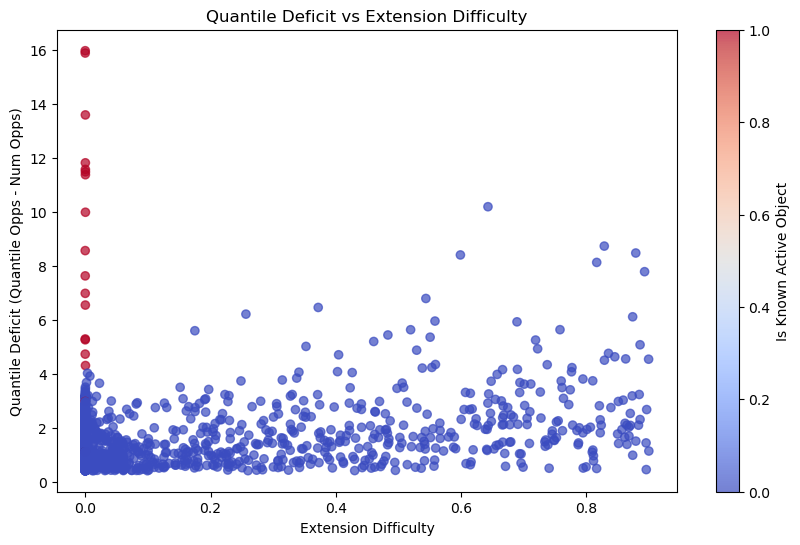

In [110]:
# plot DeltaQ vs extension difficulty, RED is known active object, BLUE is not so listed in the known active json
tempout3 = combined_rankings[combined_rankings["DeltaQ"]>0]

plt.figure(figsize=(10,6))
plt.scatter(tempout3["extension_difficulty"], tempout3["DeltaQ"], c=tempout3["Known / Strong Suspect"], cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Is Known Active Object')
plt.xlabel('Extension Difficulty')
plt.ylabel('Quantile Deficit (Quantile Opps - Num Opps)')
plt.title('Quantile Deficit vs Extension Difficulty')
plt.show()

# Ranking Candidates, Starting with Asteroid Orbits
All predictions here are out-of-fold predictions, that is each prediction is made using training data that excludes itself.
This is possible because AutoGluon uses cross validation and we are using the predict_proba_oof method for data in the training dataset.

## First starting with an overall list of single-opposition objects
After the initial nicely-filtered list, we will also have several lists here which show the "fringe" objects where number of nights or extension_difficulty presents some skepticism for the likelihood of being a real object that is indeed recoverable (yet hasn't been)

In [111]:
# Overall Single-Opposition List, broken out further below by orbital class
# You should still pay attention to extension_difficulty as anything above 0.01 means there are
# mitigating factors that make it more likely to be very difficult to recover in the ITF and/or a mislinkage
extension_difficulty_threshold = 0.15

cols_to_show = ["Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_opps"]==1)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9993)
      &(final["a"]>1.1)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.sort_values("prob", ascending=False).head(30)

,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2008 BJ22,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,20.453314
2019 OE31,32,0.000308,12.392776,10.0,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,16.613079
2025 HV38,48,0.000006,16.986370,18.0,0.999995,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,20.680737
2007 VB146,13,0.000349,11.003468,4.0,0.999995,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,14.672216
2015 BC566,52,0.000009,9.582509,11.0,0.999994,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,13.266108
2025 VZ8,50,0.000025,8.646651,15.0,0.999994,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,12.565472
2001 BV70,32,0.000310,12.499905,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,16.181974
2009 FP8,22,0.000200,7.565283,7.0,0.999991,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,11.568607
2016 WL89,11,0.175029,6.614906,NaN,0.999989,E2026-KC9,9,9,2.459778,0.059848,0.69611,18.24,2.312564,2.606992,3.487818,0.92,11.141754


In [112]:
# Sort by DeltaQ instead of prob
extension_difficulty_threshold = 0.002000

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.15,20)
      &final["extension_difficulty"].between(0,extension_difficulty_threshold)]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,15.98637,48,0.000006,16.986370,18.0,0.999995,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737
2008 BJ22,15.900511,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2008 GO98,13.608479,1549,0.000257,20.608479,NaN,0.999997,MPO969452,<NA>,0,3.97198,0.27862,15.55684,12.91,2.865306,5.078655,2.926703,0.88,0.999997,24.577824
2010 RH69,11.834263,31,0.000246,14.834263,11.0,0.999995,MPO619842,<NA>,5,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.999995,18.671633
2003 BM80,11.589455,222,0.000257,18.589455,NaN,0.999996,MPO984040,<NA>,0,4.234979,0.187734,5.81294,13.62,3.439928,5.03003,2.991765,1.16,0.999996,22.535192
2001 BV70,11.499905,32,0.000310,12.499905,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974
2019 OE31,11.392776,32,0.000308,12.392776,10.0,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079
2007 VB146,10.003468,13,0.000349,11.003468,4.0,0.999995,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999995,14.672216
2015 BC566,8.582509,52,0.000009,9.582509,11.0,0.999994,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108


In [113]:
# NEW WOW tight ext diff
extension_difficulty_threshold = 0.000500

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["extension_difficulty"].between(0,extension_difficulty_threshold)]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,15.98637,48,0.000006,16.986370,18.0,0.999995,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737
2008 BJ22,15.900511,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2008 GO98,13.608479,1549,0.000257,20.608479,NaN,0.999997,MPO969452,<NA>,0,3.97198,0.27862,15.55684,12.91,2.865306,5.078655,2.926703,0.88,0.999997,24.577824
2010 RH69,11.834263,31,0.000246,14.834263,11.0,0.999995,MPO619842,<NA>,5,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.999995,18.671633
2003 BM80,11.589455,222,0.000257,18.589455,NaN,0.999996,MPO984040,<NA>,0,4.234979,0.187734,5.81294,13.62,3.439928,5.03003,2.991765,1.16,0.999996,22.535192
2001 BV70,11.499905,32,0.000310,12.499905,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974
2019 OE31,11.392776,32,0.000308,12.392776,10.0,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079
2007 VB146,10.003468,13,0.000349,11.003468,4.0,0.999995,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999995,14.672216
2015 BC566,8.582509,52,0.000009,9.582509,11.0,0.999994,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108


In [114]:
# WOW sort by EXT DIFF
extension_difficulty_threshold = 0.000500

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["DeltaQ"].between(3.5,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2008 BJ22,15.900511,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2025 HV38,15.98637,48,0.000006,16.986370,18.0,0.999995,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737
2015 BC566,8.582509,52,0.000009,9.582509,11.0,0.999994,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108
2025 VZ8,7.646651,50,0.000025,8.646651,15.0,0.999994,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,0.999994,12.565472
2018 BJ11,5.278018,46,0.000026,6.278018,13.0,0.999981,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.999981,10.234798
2017 QN84,4.748344,213,0.000029,8.748344,64.0,0.999995,MPO907046,<NA>,0,3.771028,0.34354,12.07174,14.97,2.47553,5.066526,2.943421,1.13,0.999995,12.298758
2010 TR241,5.30962,12,0.000039,6.309620,4.0,0.999977,E2026-GD6,36,5,3.051346,0.099911,12.41829,16.97,2.746481,3.35621,3.193443,0.8,0.999977,9.978014
2021 AY8,6.999564,24,0.000041,7.999564,7.0,0.999989,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.999989,11.701427
2009 FP8,6.565283,22,0.000200,7.565283,7.0,0.999991,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607


In [115]:
# WOW sort by EXT DIFF U != 9 (avoiding really uncertain orbits)
extension_difficulty_threshold = 0.000500

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &(final["U"]!=9)
      &final["DeltaQ"].between(3.6,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2008 BJ22,15.900511,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2025 HV38,15.98637,48,0.000006,16.986370,18.0,0.999995,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737
2015 BC566,8.582509,52,0.000009,9.582509,11.0,0.999994,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108
2025 VZ8,7.646651,50,0.000025,8.646651,15.0,0.999994,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,0.999994,12.565472
2018 BJ11,5.278018,46,0.000026,6.278018,13.0,0.999981,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.999981,10.234798
2017 QN84,4.748344,213,0.000029,8.748344,64.0,0.999995,MPO907046,<NA>,0,3.771028,0.34354,12.07174,14.97,2.47553,5.066526,2.943421,1.13,0.999995,12.298758
2010 TR241,5.30962,12,0.000039,6.309620,4.0,0.999977,E2026-GD6,36,5,3.051346,0.099911,12.41829,16.97,2.746481,3.35621,3.193443,0.8,0.999977,9.978014
2021 AY8,6.999564,24,0.000041,7.999564,7.0,0.999989,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.999989,11.701427
2009 FP8,6.565283,22,0.000200,7.565283,7.0,0.999991,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607


In [116]:
# WOW Comets
extension_difficulty_threshold = 0.0100

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "Num_opps", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &~final["a"].between(4.9,5.5)
      &(final["TJ"]<3.03)
      &(final["Num_opps"]<=13)
      &final["prob"].between(0.85,1000)
      &final["DeltaQ"].between(2.2,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,Num_opps,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2020 RR70,2.418932,26,0.000019,1,3.418932,6.0,0.992365,MPO605367,38,5,3.980941,0.159986,5.93189,16.10,3.344046,4.617837,3.024624,0.34,0.992365,7.809955
2018 BJ11,5.278018,46,0.000026,1,6.278018,13.0,0.999981,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.999981,10.234798
2017 QN84,4.748344,213,0.000029,4,8.748344,64.0,0.999995,MPO907046,<NA>,0,3.771028,0.34354,12.07174,14.97,2.47553,5.066526,2.943421,1.13,0.999995,12.298758
2024 XE22,2.992724,36,0.000091,1,3.992724,10.0,0.997871,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,2.7273,0.81,0.997871,7.697018
2010 RH69,11.834263,31,0.000246,3,14.834263,11.0,0.999995,MPO619842,<NA>,5,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.999995,18.671633
2008 GO98,13.608479,1549,0.000257,7,20.608479,NaN,0.999997,MPO969452,<NA>,0,3.97198,0.27862,15.55684,12.91,2.865306,5.078655,2.926703,0.88,0.999997,24.577824
2003 BM80,11.589455,222,0.000257,7,18.589455,NaN,0.999996,MPO984040,<NA>,0,4.234979,0.187734,5.81294,13.62,3.439928,5.03003,2.991765,1.16,0.999996,22.535192
2000 EJ37,2.8819,1682,0.000257,11,13.881900,NaN,0.999993,MPO983854,<NA>,0,4.617269,0.705537,10.07981,13.71,1.359614,7.874924,2.441433,0.54,0.999993,17.919069
2019 OE31,11.392776,32,0.000308,1,12.392776,10.0,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079


In [117]:
# NEW Idea v_mag_avg - NOT PART OF THE PAPER AS THIS IS EXPERIMENTAL
cols_to_show = ["v_mag_avg", "v_mag_min", "Num_obs", "extension_difficulty", "DeltaQ", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
    #   &(final["U"]!=9)
      &(final["extension_difficulty"].between(0,0.65))
      &(final["prob"]>.999)
      &( (final["v_mag_avg"]-final["v_mag_min"])<3)
      &final["DeltaQ"].between(3,1000)]

tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,v_mag_avg,v_mag_min,Num_obs,extension_difficulty,DeltaQ,quantile_Opps,nights_total,prob,Ref,Arc_length,...,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2001 BV70,17.647826,16.50,32,0.000310,11.499905,12.499905,8.0,0.999992,MPO 13809,50,...,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974
2017 QN84,19.107900,17.03,213,0.000029,4.748344,8.748344,64.0,0.999995,MPO907046,<NA>,...,3.771028,0.34354,12.07174,14.97,2.47553,5.066526,2.943421,1.13,0.999995,12.298758
2008 BJ22,19.349630,18.40,53,0.000005,15.900511,16.900511,13.0,0.999995,MPO732621,83,...,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2002 CW116,19.507826,18.20,27,0.000399,4.32557,5.325570,7.0,0.999852,E2024-D99,88,...,2.690341,0.231179,8.13919,17.52,2.068389,3.312293,3.319062,0.53,0.999852,8.345676
2010 RH69,19.959394,17.80,31,0.000246,11.834263,14.834263,11.0,0.999995,MPO619842,<NA>,...,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.999995,18.671633
2006 JE41,20.243750,19.70,16,0.550558,5.376326,6.376326,3.0,0.999986,MPO102346,14,...,2.267336,0.191752,2.08041,18.42,1.83257,2.702102,3.589674,0.35,0.999986,10.292957
2009 FP8,20.246154,19.30,22,0.000200,6.565283,7.565283,7.0,0.999991,MPO166339,35,...,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607
2003 QY80,20.360000,19.80,7,0.598876,8.42177,9.421770,3.0,0.999988,MPO 50803,8,...,3.188024,0.145496,1.59877,16.67,2.724179,3.65187,3.180322,0.46,0.999988,13.168095
2007 VB146,20.371429,20.10,13,0.000349,10.003468,11.003468,4.0,0.999995,MPO130330,16,...,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999995,14.672216


In [118]:
# 2013 QC85 and 2013 DZ10 search - WORKING!
cols_to_show = ["v_mag_avg", "v_mag_min", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>=3)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["Num_opps"].between(1,1)
    #   &(final["U"]!=9)
      &(final["extension_difficulty"].between(0,0.9))
      &(final["prob"]>.99)
      &( (final["v_mag_avg"]-final["v_mag_min"])<2.5)

      # There are some bad old objects we need to filter starting with 1992
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>1992)

      &final["DeltaQ"].between(1,1000)
      ]
tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,v_mag_avg,v_mag_min,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,17.647826,16.50,32,0.000310,12.499905,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974
2005 UG561,18.366667,18.30,6,0.256885,3.417866,3.0,0.995098,MPO976062,12,7,2.960411,0.386154,7.32368,17.29,1.817237,4.103586,3.137774,0.16,0.995098,6.727694
2006 UP17,18.915789,17.90,38,0.000051,3.351343,8.0,0.993898,MPO111325,31,10,2.013725,0.238486,28.46334,18.20,1.533478,2.493971,3.646044,0.47,0.993898,6.951511
2005 XO113,19.133333,19.10,12,0.519154,7.925703,4.0,0.999994,MPO 98031,3,10,3.103499,0.306931,21.37122,16.04,2.15094,4.056058,3.045499,0.3,0.999994,11.499630
2005 WW206,19.133333,19.00,12,0.457303,19.757572,3.0,0.999994,MPO 98017,3,10,3.233998,0.086857,22.0817,13.82,2.953103,3.514893,3.06445,0.53,0.999994,23.642876
2008 BJ22,19.349630,18.40,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2001 RT107,19.488889,18.90,9,0.779056,12.556313,3.0,0.999995,MPO297823,7,10,3.105441,0.212599,9.6661,15.96,2.445227,3.765656,3.163818,0.65,0.999995,16.167107
2002 CW116,19.507826,18.20,27,0.000399,5.325570,7.0,0.999852,E2024-D99,88,5,2.690341,0.231179,8.13919,17.52,2.068389,3.312293,3.319062,0.53,0.999852,8.345676
2014 NT61,19.523571,19.27,14,0.000929,2.743677,4.0,0.990265,MPO307101,28,10,2.9358,0.29461,13.76723,17.39,2.070885,3.800715,3.16667,0.04,0.990265,6.582183


In [119]:
# 2013 DZ10 like search - U not 9, 0.997
cols_to_show = ["v_mag_avg", "v_mag_min", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>=3)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["Num_opps"].between(1,1)
    #   &(final["U"]!=9)
      &(final["extension_difficulty"].between(0,0.6))
      &(final["prob"]>.9998)
      &( (final["v_mag_avg"]-final["v_mag_min"])<2.5)
      &(final["U"]!=9)

      # There are some bad old objects we need to filter starting with 1992
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>1992)

      &final["DeltaQ"].between(1,1000)
      ]
tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,v_mag_avg,v_mag_min,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,17.647826,16.50,32,0.000310,12.499905,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974
2005 WW206,19.133333,19.00,12,0.457303,19.757572,3.0,0.999994,MPO 98017,3,10,3.233998,0.086857,22.0817,13.82,2.953103,3.514893,3.06445,0.53,0.999994,23.642876
2005 XO113,19.133333,19.10,12,0.519154,7.925703,4.0,0.999994,MPO 98031,3,10,3.103499,0.306931,21.37122,16.04,2.15094,4.056058,3.045499,0.3,0.999994,11.499630
2008 BJ22,19.349630,18.40,53,0.000005,16.900511,13.0,0.999995,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314
2002 CW116,19.507826,18.20,27,0.000399,5.325570,7.0,0.999852,E2024-D99,88,5,2.690341,0.231179,8.13919,17.52,2.068389,3.312293,3.319062,0.53,0.999852,8.345676
2006 JE41,20.243750,19.70,16,0.550558,6.376326,3.0,0.999986,MPO102346,14,10,2.267336,0.191752,2.08041,18.42,1.83257,2.702102,3.589674,0.35,0.999986,10.292957
2009 FP8,20.246154,19.30,22,0.000200,7.565283,7.0,0.999991,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607
2003 QY80,20.360000,19.80,7,0.598876,9.421770,3.0,0.999988,MPO 50803,8,10,3.188024,0.145496,1.59877,16.67,2.724179,3.65187,3.180322,0.46,0.999988,13.168095
2007 VB146,20.371429,20.10,13,0.000349,11.003468,4.0,0.999995,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999995,14.672216


In [120]:
# NEW Idea v_mag_avg Comets - NOT PART OF THE PAPER AS THIS IS EXPERIMENTAL
cols_to_show = ["DeltaQ", "v_mag_avg", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,8)
      &final["q"].between(1.05,20)
      &final["TJ"].between(2,3.03)
      &final["Num_opps"].between(0,1.5)
      &final["prob"].between(0.75,1)
      &(final["extension_difficulty"].between(0,0.6))
      &( (final["v_mag_avg"]-final["v_mag_min"])<3)
      &final["DeltaQ"].between(0.9,1000)]

tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,v_mag_avg,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,11.499905,17.647826,32,0.000310,12.499905,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974
2012 XK149,1.459364,20.410000,14,0.000071,2.459364,4.0,0.963892,MPO987382,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.963892,5.958031
2019 OE31,11.392776,20.644375,32,0.000308,12.392776,10.0,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079
2009 DP2,1.122796,21.185342,77,0.000044,2.122796,18.0,0.980490,MPO976100,22,2,6.654022,0.425542,26.76085,14.17,3.822454,9.485589,2.609461,0.58,0.980490,6.365898
2015 CP7,1.01167,21.198333,18,0.001941,2.011670,4.0,0.967608,E2026-KA3,20,7,3.961085,0.218177,6.10501,16.65,3.096866,4.825304,3.00689,0.95,0.967608,5.781054
2016 GQ379,2.691475,21.198889,9,0.335569,3.691475,3.0,0.997056,MPO870269,31,6,3.422563,0.282536,14.90329,16.78,2.455566,4.389561,3.023878,0.78,0.997056,7.372771
2009 VN6,1.680708,21.241667,12,0.589123,2.680708,3.0,0.983327,MPO167775,9,10,5.170138,0.140514,10.3425,15.10,4.443663,5.896612,2.948179,0.32,0.983327,6.876866
2020 HK47,1.427342,21.274828,30,0.000058,2.427342,7.0,0.961686,MPO600179,57,3,3.154777,0.190627,25.48715,16.90,2.553391,3.756163,3.029261,0.22,0.961686,6.020765
2025 FN32,1.089871,21.361176,16,0.000174,2.089871,5.0,0.952544,MPO913905,35,5,3.154437,0.111848,27.05033,16.97,2.801618,3.507257,3.027636,1.19,0.952544,6.005739


In [121]:
# Show specific objects in a table
cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[final.index.isin(["2024 XE22", "2008 VK110", '2008 SM113','2014 SG99','2022 GD19','2013 PM21','2012 TV407','2010 TR241','2012 XK149'])]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2010 TR241,5.30962,12,0.000039,6.309620,4.0,0.999977,E2026-GD6,36,5,3.051346,0.099911,12.41829,16.97,2.746481,3.35621,3.193443,0.8,0.999977,9.978014
2008 SM113,4.945448,13,0.722149,6.945448,3.0,0.999986,MPO213402,<NA>,4,3.18211,0.305749,3.16468,16.80,2.209183,4.155036,3.121993,0.39,0.999986,10.013613
2024 XE22,2.992724,36,0.000091,3.992724,10.0,0.997871,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,2.7273,0.81,0.997871,7.697018
2022 GD19,2.136741,10,0.249990,3.136741,3.0,0.989753,MPO706391,15,8,2.258195,0.077804,5.86239,18.86,2.082498,2.433893,3.610789,0.5,0.989753,7.514131
2012 XK149,1.459364,14,0.000071,2.459364,4.0,0.963892,MPO987382,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.963892,5.958031
2014 SG99,1.18167,12,0.641547,2.181670,4.0,0.974183,MPO311513,9,10,3.020191,0.073212,1.177,17.65,2.799078,3.241305,3.242102,0.12,0.974183,7.055120
2012 TV407,-0.047438,12,0.139877,0.952562,4.0,0.854995,MPO869515,13,9,3.053632,0.142814,0.11743,17.82,2.617529,3.489735,3.22035,0.82,0.854995,5.146305
2013 PM21,-0.215767,13,0.000155,0.784233,4.0,0.881040,E2026-K02,26,6,2.59334,0.17995,15.07903,17.90,2.126667,3.060012,3.347413,0.87,0.881040,5.525016
2008 VK110,-0.895689,24,0.000880,2.104311,9.0,0.955201,MPO791125,<NA>,4,7.171424,0.381308,7.38573,14.06,4.4369,9.905947,2.878151,0.96,0.955201,5.886453


In [122]:
# Consider carefully these 4-nighters even if extension_difficulty is above extension_difficulty_threshold as they may be real objects that are just difficult to recover in the ITF
# ... but possible with the right ITF algorithm. Note: we've seen situations where our ITF algorithm doesn't find it but someone else's does and vice versa.
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9988)
      &(final["a"]>1.1)
      &((final["extension_difficulty"]>extension_difficulty_threshold) & (final["nights_total"]>3) )
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,


In [123]:
# These objects with higher extension_difficulty may be real objects (but more likely super short arcs or mislinkages),
# but in practice we've found it unrewarding to invest too much manual effort chasing them. They should still be examined
# if one has the bandwidth and/or can use pipelines / citizen science to examine them at scale.
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9999)
      &((final["extension_difficulty"]>extension_difficulty_threshold) & (final["extension_difficulty"]<0.6))
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("extension_difficulty", ascending=True)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2016 WL89,11,0.175029,NaN,0.999989,E2026-KC9,9,9,2.459778,0.059848,0.69611,18.24,2.312564,2.606992,3.487818,0.92,0.999989,11.141754
2020 BB167,11,0.256528,3.0,0.999992,MPO871285,8,9,2.784959,0.308706,3.17923,16.99,1.925224,3.644693,3.25787,0.96,0.999992,11.676475
2015 PF156,9,0.352399,3.0,0.999958,MPO839241,27,7,2.813157,0.479451,12.58914,16.56,1.464386,4.161927,3.109065,1.02,0.999958,10.448930
2011 SV95,12,0.404479,3.0,0.999993,MPO208344,9,10,2.643084,0.303308,2.90352,17.62,1.841416,3.444751,3.325112,0.27,0.999993,9.259931
2022 QR284,9,0.460505,3.0,0.999978,MPO825492,14,9,2.92522,0.064533,0.38657,17.50,2.736447,3.113993,3.275134,1.01,0.999978,10.750879
2023 WZ43,9,0.483145,3.0,0.999995,MPO793415,26,7,2.313057,0.290108,8.063,17.78,1.64202,2.984093,3.51295,0.44,0.999995,10.497023
2015 RJ402,13,0.519404,3.0,0.999988,MPO913218,8,9,2.953556,0.097722,1.69146,17.29,2.664927,3.242184,3.260609,0.68,0.999988,11.423441
2014 SA98,12,0.529061,3.0,0.999932,MPO311512,9,10,3.440696,0.08092,13.00138,16.54,3.162275,3.719117,3.0917,0.27,0.999932,10.081097
2014 TT125,11,0.543760,3.0,0.999995,MPO838934,29,7,2.67137,0.310983,12.77307,16.81,1.840619,3.502122,3.276005,0.87,0.999995,11.787653


## List by Orbital Class
### Asteroidal

In [124]:
# Single-opposition asteroid-only list (T_J > 3.05), sorted by prob
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.07)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737,0.000006
2008 BJ22,53,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314,0.000005
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999995,14.672216,0.000349
2015 BC566,52,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108,0.000009
2025 VZ8,50,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,0.999994,12.565472,0.000025
2021 AY8,24,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.999989,11.701427,0.000041
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607,0.000200
2010 TR241,12,E2026-GD6,36,5,3.051346,0.099911,12.41829,16.97,2.746481,3.35621,3.193443,0.8,0.999977,9.978014,0.000039
2002 CW116,27,E2024-D99,88,5,2.690341,0.231179,8.13919,17.52,2.068389,3.312293,3.319062,0.53,0.999852,8.345676,0.000399


In [125]:
# Single-opposition asteroid-only TIGHTER with more than 16 observations
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>16)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.07)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(10)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737,0.000006
2008 BJ22,53,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314,0.000005
2015 BC566,52,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108,0.000009
2025 VZ8,50,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,0.999994,12.565472,0.000025
2021 AY8,24,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.999989,11.701427,0.000041
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607,0.000200
2002 CW116,27,E2024-D99,88,5,2.690341,0.231179,8.13919,17.52,2.068389,3.312293,3.319062,0.53,0.999852,8.345676,0.000399
2017 PZ20,17,MPO621245,53,5,2.793188,0.057697,3.32275,17.70,2.632029,2.954346,3.323236,0.15,0.999140,9.357955,0.007490
2021 RR149,17,MPO665988,80,4,3.19797,0.095742,12.14615,16.90,2.891789,3.504152,3.152806,0.12,0.998808,8.406218,0.000276


In [126]:
# 2025 and 2026 objects
cols_to_show = ["Num_obs","extension_difficulty","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps"]
tempout = final[(final["Arc_length"]>9)
      &(final["Num_obs"]>6)
      &(final["prob"]>0.997)
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>=2025)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.to_clipboard()
tempout.head(10)

,Num_obs,extension_difficulty,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,0.000006,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737
2025 VZ8,50,0.000025,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,0.999994,12.565472
2025 QB175,8,0.022799,E2026-HE1,11,9,2.734449,0.170421,0.38038,18.07,2.268443,3.200456,3.331418,0.11,0.999659,8.274145
2025 ON569,9,0.223026,E2026-HH3,10,9,3.135683,0.085831,0.05954,17.41,2.866545,3.404821,3.206191,0.09,0.997719,8.741894
2025 OZ131,12,0.000058,MPO978819,10,9,3.224998,0.240056,10.12319,17.12,2.450819,3.999178,3.118087,0.5,0.999109,7.262190
2025 TY59,9,0.513700,MPO963394,20,9,2.735115,0.190085,8.93207,17.68,2.215211,3.255018,3.308671,0.28,0.997794,7.706600
2025 OB391,12,0.000308,E2026-HC6,11,9,3.115893,0.087108,1.9981,17.44,2.844473,3.387312,3.210733,0.55,0.997227,8.554612
2025 PP218,10,0.111966,E2026-HE1,12,9,2.986713,0.205254,0.86772,17.79,2.373677,3.599749,3.22492,0.18,0.997476,7.582716


In [127]:
# Same thing, but different sort
# Single-opposition asteroid-only list (T_J > 3.05), sorted by Expeected Number of Oppositions
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.99)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.15)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)].sort_values("exp_Num_opps", ascending=False)
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.483844,0.047402,7.24018,15.42,2.366106,2.601583,3.464041,0.84,0.999995,20.680737,0.000006
2008 BJ22,53,MPO732621,83,4,3.072986,0.042267,11.51171,15.05,2.9431,3.202873,3.19791,0.67,0.999995,20.453314,0.000005
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999995,14.672216,0.000349
2015 BC566,52,MPO771428,39,5,3.065828,0.03653,11.68739,16.33,2.953833,3.177822,3.199504,0.42,0.999994,13.266108,0.000009
2025 VZ8,50,MPO988040,43,6,2.620758,0.086097,12.10021,16.76,2.395117,2.846399,3.368052,0.65,0.999994,12.565472,0.000025
2021 AY8,24,E2024-S20,101,4,2.723372,0.057088,5.00709,17.52,2.567901,2.878843,3.349587,0.85,0.999989,11.701427,0.000041
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999991,11.568607,0.000200
2010 TR241,12,E2026-GD6,36,5,3.051346,0.099911,12.41829,16.97,2.746481,3.35621,3.193443,0.8,0.999977,9.978014,0.000039
2005 XN58,11,MPO172122,23,10,2.552751,0.048836,1.87253,18.23,2.428085,2.677417,3.436675,0.2,0.999584,9.680551,0.003687


### On to Comet Orbits

In [128]:
# NEW multiopp 3+ Comets
cols_to_show = ["Num_opps", "exp_Num_opps", "poisson_cdf", "DeltaQ", "quantile_Opps", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Num_opps"]>=3)
      &(final["prob"]>.999)
      &(final["q"]>1.1)
      &(final["TJ"]<3.05)
      &(final["a"].between(1.1,10))
      &~(final["a"].between(4.9,5.5))
      &(final["DeltaQ"]>-3)
      &((final["extension_difficulty"].between(0,0.25)))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,Num_opps,exp_Num_opps,poisson_cdf,DeltaQ,quantile_Opps,extension_difficulty,nights_total,prob,Ref,Arc_length,...,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2010 RH69,3,18.671633,0.000004,11.834263,14.834263,0.000246,11.0,0.999995,MPO619842,<NA>,...,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.999995,18.671633
2008 GO98,7,24.577824,0.000018,13.608479,20.608479,0.000257,NaN,0.999997,MPO969452,<NA>,...,3.97198,0.27862,15.55684,12.91,2.865306,5.078655,2.926703,0.88,0.999997,24.577824
2003 BM80,7,22.535192,0.000083,11.589455,18.589455,0.000257,NaN,0.999996,MPO984040,<NA>,...,4.234979,0.187734,5.81294,13.62,3.439928,5.03003,2.991765,1.16,0.999996,22.535192
2017 QN84,4,12.298758,0.003921,4.748344,8.748344,0.000029,64.0,0.999995,MPO907046,<NA>,...,3.771028,0.34354,12.07174,14.97,2.47553,5.066526,2.943421,1.13,0.999995,12.298758
2016 BA112,5,11.047367,0.028369,1.653715,6.653715,0.000025,12.0,0.999959,MPO918846,<NA>,...,4.014915,0.045245,5.90958,15.93,3.83326,4.19657,3.041668,0.64,0.999959,11.047367
2017 YR16,4,9.489371,0.030331,1.894464,5.894464,0.000007,28.0,0.999988,E2024-NF3,<NA>,...,3.19322,0.216145,27.10575,16.18,2.503023,3.883418,2.991147,0.92,0.999988,9.489371
1975 VY5,26,36.879631,0.036015,-1.789534,24.210466,0.000257,NaN,0.999991,MPO964332,<NA>,...,3.187488,0.125122,24.32011,11.22,2.788663,3.586313,3.047601,0.45,0.999991,36.879631
2019 WY11,4,9.049614,0.040982,1.513404,5.513404,0.000035,25.0,0.999950,E2026-HE1,<NA>,...,3.081627,0.215676,27.23179,16.38,2.416994,3.74626,3.024777,0.65,0.999950,9.049614
2014 JZ56,4,8.993244,0.042574,0.873018,4.873018,0.000037,14.0,0.999646,E2024-H40,<NA>,...,2.975344,0.209056,29.09074,16.47,2.35333,3.597358,3.041129,0.38,0.999646,8.993244


In [129]:
# NEW multiopp comet 2+ (is that the only difference from previous?)
cols_to_show = ["Num_opps", "DeltaQ", "exp_Num_opps", "poisson_cdf", "quantile_Opps", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Num_opps"]>=2)
      &(~final["a"].between(5,5.4))
      &(final["prob"]>.9)
      &(final["q"]>1.1)
      &(final["TJ"]<3.05)
      &(final["a"].between(1.1,9))
      &~(final["a"].between(4.9,5.5))
      &((final["extension_difficulty"].between(0,0.25)))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,Num_opps,DeltaQ,exp_Num_opps,poisson_cdf,quantile_Opps,extension_difficulty,nights_total,prob,Ref,Arc_length,...,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2010 RH69,3,11.834263,18.671633,0.000004,14.834263,0.000246,11.0,0.999995,MPO619842,<NA>,...,4.532514,0.056522,11.54792,13.95,4.276327,4.788701,2.97391,0.96,0.999995,18.671633
2008 GO98,7,13.608479,24.577824,0.000018,20.608479,0.000257,NaN,0.999997,MPO969452,<NA>,...,3.97198,0.27862,15.55684,12.91,2.865306,5.078655,2.926703,0.88,0.999997,24.577824
2003 BM80,7,11.589455,22.535192,0.000083,18.589455,0.000257,NaN,0.999996,MPO984040,<NA>,...,4.234979,0.187734,5.81294,13.62,3.439928,5.03003,2.991765,1.16,0.999996,22.535192
2017 QN84,4,4.748344,12.298758,0.003921,8.748344,0.000029,64.0,0.999995,MPO907046,<NA>,...,3.771028,0.34354,12.07174,14.97,2.47553,5.066526,2.943421,1.13,0.999995,12.298758
1980 TU6,34,-8.905188,52.160664,0.004505,25.094812,0.000257,NaN,0.999988,E2026-L01,<NA>,...,3.998128,0.120851,13.4771,10.11,3.51495,4.481306,2.993785,0.75,0.999988,52.160664
2013 TS210,2,1.596381,7.816402,0.008564,3.596381,0.000474,5.0,0.991814,MPO600179,<NA>,...,3.570502,0.069471,18.34316,16.30,3.322455,3.818549,3.026026,0.26,0.991814,7.816402
1984 SH5,32,-6.117203,46.512066,0.014857,25.882797,0.000257,NaN,0.999990,MPO980580,<NA>,...,3.929532,0.20825,4.99044,10.57,3.111208,4.747856,3.01762,0.73,0.999990,46.512066
2022 FW21,2,0.67415,7.038198,0.016792,2.674150,0.000130,5.0,0.987065,MPO962471,<NA>,...,3.919455,0.129933,3.6734,16.43,3.410187,4.428723,3.045094,0.68,0.987065,7.038198
2019 GR44,2,0.840653,6.960133,0.017954,2.840653,0.000855,8.0,0.981220,MPO687862,<NA>,...,3.167549,0.14561,26.62505,16.70,2.706322,3.628777,3.022752,0.27,0.981220,6.960133


In [130]:
# Comets with stricter TJ
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "quantile_Opps", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9)
      &(final["TJ"]<3.01)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("prob", ascending=False)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,quantile_Opps,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2019 OE31,32,0.000308,10.0,12.392776,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,16.613079
2001 BV70,32,0.000310,8.0,12.499905,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,16.181974
2018 BJ11,46,0.000026,13.0,6.278018,0.999981,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,10.234798
2024 XE22,36,0.000091,10.0,3.992724,0.997871,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,2.7273,0.81,7.697018
2009 DP2,77,0.000044,18.0,2.122796,0.980490,MPO976100,22,2,6.654022,0.425542,26.76085,14.17,3.822454,9.485589,2.609461,0.58,6.365898
2023 WD46,10,0.058073,3.0,2.465432,0.970085,MPO811404,26,7,3.41887,0.226188,41.89114,16.25,2.645561,4.192178,2.697437,0.41,6.356899
2023 XN31,11,0.058588,3.0,2.418926,0.969042,MPO793527,27,7,4.011887,0.278117,6.37673,16.25,2.896114,5.12766,2.973386,0.45,6.191978
2015 CP7,18,0.001941,4.0,2.011670,0.967608,E2026-KA3,20,7,3.961085,0.218177,6.10501,16.65,3.096866,4.825304,3.00689,0.95,5.781054
2012 XK149,14,0.000071,4.0,2.459364,0.963892,MPO987382,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,5.958031


In [131]:
# Single-opp Comets strict TJ and extension difficulty
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "quantile_Opps", "TJ", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["q"]>0.9)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9)
      &(final["TJ"]<3.01)
      &((final["extension_difficulty"].between(0,0.05))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("quantile_Opps", ascending=False)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,quantile_Opps,TJ,prob,Ref,Arc_length,U,a,e,i,H,q,Q,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,
2001 BV70,32,0.000310,8.0,12.499905,2.947403,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,0.58,0.999992,16.181974
2019 OE31,32,0.000308,10.0,12.392776,3.006111,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,0.65,0.999995,16.613079
2018 BJ11,46,0.000026,13.0,6.278018,2.988437,0.999981,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,0.47,0.999981,10.234798
2024 XE22,36,0.000091,10.0,3.992724,2.7273,0.997871,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,0.81,0.997871,7.697018
2012 XK149,14,0.000071,4.0,2.459364,2.959026,0.963892,MPO987382,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,0.77,0.963892,5.958031
2021 QP61,14,0.000145,4.0,2.435894,3.005804,0.963858,MPO656386,32,4,3.200702,0.189764,26.34171,17.00,2.593325,3.808079,0.11,0.963858,6.400947
2009 DP2,77,0.000044,18.0,2.122796,2.609461,0.980490,MPO976100,22,2,6.654022,0.425542,26.76085,14.17,3.822454,9.485589,0.58,0.980490,6.365898
2015 CP7,18,0.001941,4.0,2.011670,3.00689,0.967608,E2026-KA3,20,7,3.961085,0.218177,6.10501,16.65,3.096866,4.825304,0.95,0.967608,5.781054
2021 FE48,14,0.000172,4.0,1.724673,3.001675,0.926912,MPO646208,51,4,3.190324,0.109621,28.28464,16.80,2.840597,3.540051,0.16,0.926912,6.175496


In [132]:
# NEW Comets a > 4 (for whatever reason, these are more likely true and you can set a lower probability threshold--even as low as 0.8--and still get relevant flags of objects worth checking)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["a"]>4)&(final["a"]<10)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.7)
      &(final["TJ"]<3.05)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2019 OE31,32,0.000308,10.0,0.999995,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079
2018 BJ11,46,0.000026,13.0,0.999981,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.999981,10.234798
2024 XE22,36,0.000091,10.0,0.997871,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,2.7273,0.81,0.997871,7.697018
2023 XN31,11,0.058588,3.0,0.969042,MPO793527,27,7,4.011887,0.278117,6.37673,16.25,2.896114,5.12766,2.973386,0.45,0.969042,6.191978
2009 DP2,77,0.000044,18.0,0.980490,MPO976100,22,2,6.654022,0.425542,26.76085,14.17,3.822454,9.485589,2.609461,0.58,0.980490,6.365898
2022 QJ32,71,0.000024,17.0,0.924550,E2023-P46,189,4,5.911361,0.541555,40.64909,15.26,2.710035,9.112687,2.239884,0.21,0.924550,5.475465
2021 GN33,23,0.000013,6.0,0.835008,MPO641177,33,4,4.000266,0.161444,26.5234,16.16,3.354446,4.646085,2.849178,0.73,0.835008,4.914236
2020 OX7,364,0.000007,62.0,0.844371,MPO600154,168,2,4.203042,0.571363,17.80043,16.80,1.801579,6.604504,2.642546,0.27,0.844371,4.912955
2024 SJ18,12,0.000094,4.0,0.756703,MPO872837,8,9,5.433438,0.16061,21.26977,15.32,4.560772,6.306104,2.837454,0.72,0.756703,4.037333


In [133]:
# Single-opp Periodic Comets (excluding Trojans)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<20)
      &(final["Arc_length"]>14)
      &(final["Num_obs"]>7)
      &(final["TJ"]<=3.05)
      &(final["prob"]>0.8)
      &(final["Tp"]>2450000)
      &(final["a"].between(1.1,10))
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2001 BV70,32,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974,0.000310
2019 OE31,32,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079,0.000308
2018 BJ11,46,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.999981,10.234798,0.000026
2025 DP57,13,MPO913733,31,8,3.873571,0.156857,3.55072,16.26,3.265973,4.481168,3.044246,0.76,0.996976,8.176641,0.000263
2024 XE22,36,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,2.7273,0.81,0.997871,7.697018,0.000091
2020 RR70,26,MPO605367,38,5,3.980941,0.159986,5.93189,16.10,3.344046,4.617837,3.024624,0.34,0.992365,7.809955,0.000019
2023 WD46,10,MPO811404,26,7,3.41887,0.226188,41.89114,16.25,2.645561,4.192178,2.697437,0.41,0.970085,6.356899,0.058073
2010 AV124,23,MPO929492,179,7,3.141414,0.207915,24.31662,16.68,2.488266,3.794563,3.041495,0.39,0.963543,6.060915,0.001608
2012 XK149,14,MPO987382,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.963892,5.958031,0.000071


In [134]:
# Comets a > 4 (somehow this list tends to be better at turning up real comets? there are lots with a<4 which are just insufficiently linked/observed)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<20)
      &(final["Arc_length"]>14)
      &(final["a"]>4)
      &(final["Num_obs"]>7)
      &(final["TJ"]<=3.05)
      &(final["prob"]>0.7)
      &(final["Tp"]>2450000)
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2019 OE31,32,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,4.818685,3.006111,0.65,0.999995,16.613079,0.000308
2018 BJ11,46,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,5.11915,2.988437,0.47,0.999981,10.234798,0.000026
2024 XE22,36,MPO988022,22,4,5.859696,0.226623,27.15575,14.26,4.531753,7.187639,2.7273,0.81,0.997871,7.697018,0.000091
2023 XN31,11,MPO793527,27,7,4.011887,0.278117,6.37673,16.25,2.896114,5.12766,2.973386,0.45,0.969042,6.191978,0.058588
2009 DP2,77,MPO976100,22,2,6.654022,0.425542,26.76085,14.17,3.822454,9.485589,2.609461,0.58,0.980490,6.365898,0.000044
2022 QJ32,71,E2023-P46,189,4,5.911361,0.541555,40.64909,15.26,2.710035,9.112687,2.239884,0.21,0.924550,5.475465,0.000024
2021 GN33,23,MPO641177,33,4,4.000266,0.161444,26.5234,16.16,3.354446,4.646085,2.849178,0.73,0.835008,4.914236,0.000013
2020 OX7,364,MPO600154,168,2,4.203042,0.571363,17.80043,16.80,1.801579,6.604504,2.642546,0.27,0.844371,4.912955,0.000007
2021 QR50,31,E2021-V29,63,3,4.000219,0.199521,4.69409,16.65,3.202092,4.798347,3.013313,0.95,0.708900,4.253967,0.000092


In [135]:
# Comets a < 4 (somehow a lot of these are just insufficiently linked/observed and a bit of archival work shows them to be simple ACOs)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<20)
      &(final["Arc_length"]>14)
      &(final["a"]<4)
      &(final["Num_obs"]>7)
      &(final["TJ"]<=3.05)
      &(final["prob"]>0.7)
      &(final["Tp"]>2450000)
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2001 BV70,32,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.181974,0.000310
2025 DP57,13,MPO913733,31,8,3.873571,0.156857,3.55072,16.26,3.265973,4.481168,3.044246,0.76,0.996976,8.176641,0.000263
2020 RR70,26,MPO605367,38,5,3.980941,0.159986,5.93189,16.10,3.344046,4.617837,3.024624,0.34,0.992365,7.809955,0.000019
2023 WD46,10,MPO811404,26,7,3.41887,0.226188,41.89114,16.25,2.645561,4.192178,2.697437,0.41,0.970085,6.356899,0.058073
2010 AV124,23,MPO929492,179,7,3.141414,0.207915,24.31662,16.68,2.488266,3.794563,3.041495,0.39,0.963543,6.060915,0.001608
2012 XK149,14,MPO987382,36,6,3.950606,0.328514,4.00146,16.64,2.652778,5.248435,2.959026,0.77,0.963892,5.958031,0.000071
2021 QP61,14,MPO656386,32,4,3.200702,0.189764,26.34171,17.00,2.593325,3.808079,3.005804,0.11,0.963858,6.400947,0.000145
2020 HK47,30,MPO600179,57,3,3.154777,0.190627,25.48715,16.90,2.553391,3.756163,3.029261,0.22,0.961686,6.020765,0.000058
2020 FY28,20,MPO604809,35,5,3.139833,0.177755,24.49458,17.10,2.581712,3.697954,3.048411,0.28,0.966707,6.276704,0.000015


In [136]:
# JFC / Centaur List (see https://arxiv.org/pdf/2512.11204)
cols_to_show = ["poisson_cdf", "extension_difficulty","Num_opps","Ref","Arc_length","U","a","e","i","H","q","TJ","prob", "exp_Num_opps"]
tempout = final[((final["Arc_length"]>11)| (final["Arc_length"].isna()))
      &(final["Num_obs"]>7)
      &(final["extension_difficulty"]<0.5)
      &(final["a"].between(4.05,5.05))
      &(final["TJ"]<=3.05)
      &(final["prob"]>0.8)
      &(final["Orbital_period"]<20)].sort_values("poisson_cdf", ascending=True)
tempout = tempout[cols_to_show]
tempout.head(10)

,poisson_cdf,extension_difficulty,Num_opps,Ref,Arc_length,U,a,e,i,H,q,TJ,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,
2019 OE31,1.657013e-07,0.000308,1,E2024-JA9,137,3,4.380092,0.100133,5.22173,14.64,3.941499,3.006111,0.999995,16.613079
2010 RH69,3.697311e-06,0.000246,3,MPO619842,<NA>,5,4.532514,0.056522,11.54792,13.95,4.276327,2.97391,0.999995,18.671633
2003 BM80,8.347833e-05,0.000257,7,MPO984040,<NA>,0,4.234979,0.187734,5.81294,13.62,3.439928,2.991765,0.999996,22.535192
2018 BJ11,9.758386e-05,0.000026,1,MPO750185,107,5,4.1806,0.224501,3.42476,15.55,3.242051,2.988437,0.999981,10.234798
2020 OX7,1.998136e-02,0.000007,1,MPO600154,168,2,4.203042,0.571363,17.80043,16.80,1.801579,2.642546,0.844371,4.912955
2000 EJ37,5.101693e-02,0.000257,11,MPO983854,<NA>,0,4.617269,0.705537,10.07981,13.71,1.359614,2.441433,0.999993,17.919069
2010 LV121,5.165018e-02,0.000035,3,E2024-FA5,<NA>,0,4.922146,0.448317,19.81144,15.27,2.715467,2.692973,0.994940,7.251321
2014 QV343,7.360868e-02,0.000049,2,E2023-W85,<NA>,2,4.27106,0.28584,9.78836,16.03,3.050219,2.92937,0.923738,5.271262
2008 QZ44,8.233785e-02,0.000075,3,MPO972217,<NA>,0,4.191985,0.44029,11.35376,15.94,2.346296,2.821466,0.987786,6.600872


### Trojans and Multi-opp active asteroid lists, but they've never turned up anything
It's not surprising that the Trojans haven't turned up much (small population). It'a also not surprising that multi-opp active asteroids are a bust, probably because most MBA active asteroids are one-time or impulsive (not recurrent)

In [137]:
# Trojans (never had a true ActivitySCOPE alert for these... they always so far turn out to be recoverable in the archives)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["a"].between(5,5.4))
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(5)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2026 FR24,18,0.017922,3.0,0.996144,E2026-J03,11,8,5.262204,0.043605,7.48669,14.81,5.032747,5.491662,2.981053,0.04,0.996144,8.927570
2021 UJ44,14,0.041665,3.0,0.996912,MPO666572,12,7,5.264068,0.044307,10.38618,14.90,5.030832,5.497304,2.965197,0.1,0.996912,8.582588
2025 TD66,13,0.000050,4.0,0.995627,MPO963414,39,6,5.294156,0.099609,6.06457,14.93,4.766809,5.821503,2.978958,0.75,0.995627,8.357043
2025 CY15,12,0.000244,4.0,0.996337,MPO919178,53,5,5.220141,0.122212,1.81211,15.27,4.582176,5.858106,2.983997,0.99,0.996337,8.202207
2024 QE16,17,0.000017,5.0,0.991935,MPO872107,38,5,5.106234,0.030712,19.45384,14.93,4.949412,5.263056,2.886271,1.17,0.991935,8.030889


In [138]:
# Another Multi-opp asteroid list, ensuring no bad linkages by requiring at least x nights in the second-most observed opp
cols_to_show = ["poisson_cdf", "extension_difficulty", "opp_with_second_most_nights", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Num_opps"]==2)
      &(final["prob"]>.99)
      &(final["a"]>1.1)
      &(final["opp_with_second_most_nights"]>2)
      &(final["TJ"]>3.05)
      &(final["opp_with_second_most_nights"]>1)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(5)

,poisson_cdf,extension_difficulty,opp_with_second_most_nights,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,
2017 UR48,0.002771,0.000153,3.0,8.0,0.997874,MPO645806,<NA>,2,2.901774,0.10591,9.67592,17.40,2.594445,3.209102,3.257114,0.11,0.997874,9.096545
2015 VF69,0.003370,0.000021,7.0,15.0,0.999598,E2020-V16,<NA>,2,3.092309,0.150258,7.81861,17.00,2.627663,3.556954,3.192744,0.23,0.999598,8.876334
2020 OA143,0.003646,0.000169,3.0,11.0,0.997322,MPO987838,<NA>,2,2.953668,0.083342,6.53152,17.45,2.707502,3.199835,3.253447,0.38,0.997322,8.787603
2021 RC158,0.003723,0.000190,4.0,11.0,0.998117,MPO681017,<NA>,3,3.037169,0.094814,11.0748,17.10,2.749203,3.325134,3.205946,0.19,0.998117,8.763725
2014 HB254,0.004647,0.000689,3.0,6.0,0.999011,MPO678015,<NA>,4,2.627037,0.104586,11.4469,17.60,2.352286,2.901787,3.36579,0.1,0.999011,8.513054


# Import the Comet Orbit File from MPC
Beyond this point we aren't looking for new discoveries but mostly retrospectively looking at older discoveries.
We import the comet file only to get orbital elements etc. for prior discoveries so we can rank them for the paper (unfortunately didn't save the asteroidal MPCORB elements from prior to cometary confirmation)

In [139]:
discoveries_in_comet_file = ["P/2025 UX109 (Ye)","P/2023 JN16 (Lemmon)","P/2022 BV9 (Lemmon)","P/2017 FL36 (PANSTARRS)","489P/Denning"]

# Objects moved to Comet Orbits
comet = pd.read_json("https://www.minorplanetcenter.net/Extended_Files/allcometels.json.gz",compression='gzip')

comet = comet[comet["Orbit_type"].isin(["P","D","A"])]
# comet = comet[comet["Designation_and_name"].str[0].isin(["P","D"])]

comet["a"] = comet["Perihelion_dist"] / (1 - comet["e"])
comet["Orbital_period"] = np.sqrt(comet["a"]**3)
comet["Tp"] = 2454466 # this is just a dummy for now

# Only pulling in the magnitude data for comets from find_orb as the MPC H values in the comet file are not H assuming inert
comet_mags_fo = pd.read_fwf("./comet_orbits/comet_els_fo.txt", widths=[8, 5, 1000], names=["Packed", "Mag", "Discard"])

/Users/petervw/mambaforge/envs/automl5/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [140]:
comet["fullpacked"] = comet["Orbit_type"] + comet["Provisional_packed_desig"]
comet.drop(columns=["H"], inplace=True, errors="ignore") # Wrong H! This is the comet H and not the inert asteroidal H
cometmerge = comet.merge(comet_mags_fo, left_on="fullpacked", right_on="Packed", how="left")

cometmerge.loc[cometmerge["Designation_and_name"] == "489P/Denning", "Mag"] = 15.35
cometmerge.loc[cometmerge["Designation_and_name"] == "P/2025 UX109 (Ye)", "Mag"] = 15.00

cometmerge["H"] = cometmerge["Mag"]
cometmerge = utils.feature_engineering(cometmerge)

cometmerge["exp_Num_opps"] = predictor_reg.predict(cometmerge) + 1
cometmerge["quantile_Opps"] = predictor_quant.predict(cometmerge)[0.006] + 1

cometmerge["prob"] = predictor.predict_proba(cometmerge)[1]
cometmerge["Num_opps"] = pd.NA # no data for this in the comet file
# but for each of the discoveries_in_comet_file set Num_opps to 1 so they show up in the single-opp comet list
cometmerge.loc[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file), "Num_opps"] = 1

# Poisson_cdf business
num_opps = pd.to_numeric(cometmerge["Num_opps"], errors="coerce")
exp_num_opps = pd.to_numeric(cometmerge["exp_Num_opps"], errors="coerce")
result = poisson.cdf(num_opps - 1, exp_num_opps - 1)
cometmerge["poisson_cdf"] = pd.Series(result, index=cometmerge.index, dtype="Float64")

cometmerge['DeltaQ'] = cometmerge["quantile_Opps"]-cometmerge["Num_opps"]

In [141]:
# This is the 188 rows referenced in the paper which ActivitySCOPE would have found as likely comets if not found morphologically
cometout = cometmerge[(cometmerge["prob"] > 0.97) & ~(cometmerge["H"].isna())].sort_values("prob", ascending=False)
cometout[["Designation_and_name","a","e","i","H",'prob','poisson_cdf','DeltaQ']]#[cometout["fullpacked"].str[:4]=="PK23"]

,Designation_and_name,a,e,i,H,prob,poisson_cdf,DeltaQ
8,D/1978 R1 (Haneda-Campos),3.456798,0.628827,4.9443,14.30,0.999972,<NA>,<NA>
112,P/2013 T2 (Schwartz),3.493713,0.500129,9.4468,15.11,0.999970,<NA>,<NA>
94,P/2012 K3 (Gibbs),3.633383,0.421734,13.1785,14.31,0.999969,<NA>,<NA>
26,D/1993 F2-V (Shoemaker-Levy),6.762924,0.204622,5.7652,12.32,0.999967,<NA>,<NA>
12,D/1993 F2-D (Shoemaker-Levy),6.851481,0.214711,5.9732,12.14,0.999965,<NA>,<NA>
...,...,...,...,...,...,...,...,...
226,P/2021 P3 (PANSTARRS),4.411940,0.338387,27.1620,15.74,0.980427,<NA>,<NA>
273,P/2024 J1 (PANSTARRS),3.808956,0.307711,13.1625,16.38,0.979719,<NA>,<NA>
227,P/2021 PE20 (ATLAS),3.745564,0.670184,19.9994,16.65,0.978972,<NA>,<NA>
133,P/2015 P4 (PANSTARRS),6.049465,0.584759,8.7220,14.40,0.977678,<NA>,<NA>


In [142]:
# ActivitySCOPE discoveries that currently live in the comet file
cometmerge[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file)][["Designation_and_name","a","e","i","H",'prob','poisson_cdf','DeltaQ']]

,Designation_and_name,a,e,i,H,prob,poisson_cdf,DeltaQ
152,P/2017 FL36 (PANSTARRS),2.927577,0.033763,15.6993,16.65,0.999830,0.000034,7.232804
241,P/2022 BV9 (Lemmon),4.366555,0.233335,11.9223,13.79,0.999878,0.0,18.027784
258,P/2023 JN16 (Lemmon),2.697442,0.147305,3.7013,15.73,0.999961,0.0,18.722784
298,P/2025 UX109 (Ye),3.806430,0.324837,3.1809,15.00,0.999949,0.000001,13.212866
891,489P/Denning,4.421537,0.646954,4.0269,15.35,0.998811,0.000056,7.351749


In [143]:
raise Exception("Stop here for now.")

Exception: Stop here for now.

# This is the part for the paper
Less polished code but it can be used to verify parts of the paper

# Survey Completeness Progress

In [ ]:
# exclude legacy objects, short arcs, exclude NEOs and Trojans / things past Jupiter
# as we are mostly curious about MBA survey completeness here
sc_pre_subset = final[(final.index < "2027 ") & final["q"].between(1.3,4)
                      & ((final["Arc_length"]>7)|final["Arc_length"].isna())].copy()
sc_pre_subset = sc_pre_subset[~sc_pre_subset.index.str.contains("-")]
# also exclude known actives
sc_pre_subset = sc_pre_subset[~sc_pre_subset["Known / Strong Suspect"]]
# also exclude objects with DeltaQ > 3 as these may well be active and exclude all single-opp objects
sc_pre_subset = sc_pre_subset[(sc_pre_subset["Num_opps"]>1)]

def get_latest_principal_desig_for_exp_num_opps_range(i):
    subset = sc_pre_subset[(sc_pre_subset["exp_Num_opps"]>=i) & (sc_pre_subset["exp_Num_opps"]<i+1)]
    if len(subset)==0:
        return None
    else:
        return subset.sort_index().index[-1]

# now create a table with two columns: "exp_Num_opps_range" and "latest_principal_desig"
exp_num_opps_ranges = []
latest_principal_desigs = []
for i in range(1,30):
    exp_num_opps_ranges.append(f"{i}-{i+1}")
    latest_principal_desigs.append(get_latest_principal_desig_for_exp_num_opps_range(i))
exp_num_opps_table = pd.DataFrame({"exp_Num_opps_range": exp_num_opps_ranges, "latest_principal_desig": latest_principal_desigs})
exp_num_opps_table

,exp_Num_opps_range,latest_principal_desig
0,1-2,2026 KD2
1,2-3,2026 JR5
2,3-4,2026 JX4
3,4-5,2026 KK1
4,5-6,2026 JY8
5,6-7,2026 JT4
6,7-8,2026 HZ12
7,8-9,2026 HE13
8,9-10,2026 EZ12
9,10-11,2026 GW4


# Feature importance

In [ ]:
# reload utils and then redo feat eng
import importlib
importlib.reload(utils)

orb_training = utils.feature_engineering(orb_training.copy())

data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg+[]].astype(np.float32)
# drop any desired columns
data_df_reg.drop(columns=[], inplace=True)

# Split data_df_reg into training and test sets
train_data_reg = data_df_reg.sample(frac=0.65, random_state=42)
test_data_reg = data_df_reg.drop(train_data_reg.index)

# drop the exp_Num_opps column from both sets as this is intended only for the quantile regression model to reference the output of the main (Poisson-loss) regression model
train_data_reg = train_data_reg.drop(columns=["Shared_Fold","exp_Num_opps"], errors="ignore")
test_data_reg = test_data_reg.drop(columns=["Shared_Fold","exp_Num_opps"], errors="ignore")

In [ ]:
# Regression model training
predictor_reg_feat_imp = TabularPredictor(label="Num_opps_minus_one", eval_metric=utils.POISSON_SCORER, problem_type='regression', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_reg_feat_imp.fit(train_data_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_POISSON, num_stack_levels=0, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=220)

predictor_reg_feat_imp.feature_importance(test_data_reg)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       7.35 GB / 32.00 GB (23.0%)
Disk Space Avail:   56.81 GB / 926.35 GB (6.1%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Beginning Au

[1000]	valid_set's poisson: -15.2972	valid_set's mean_poisson_deviance: -0.369087
[1000]	valid_set's poisson: -15.2057	valid_set's mean_poisson_deviance: -0.366793
[1000]	valid_set's poisson: -15.359	valid_set's mean_poisson_deviance: -0.365827
[1000]	valid_set's poisson: -15.3374	valid_set's mean_poisson_deviance: -0.366272
[1000]	valid_set's poisson: -15.3234	valid_set's mean_poisson_deviance: -0.365395
[1000]	valid_set's poisson: -15.3323	valid_set's mean_poisson_deviance: -0.363059
[1000]	valid_set's poisson: -15.3527	valid_set's mean_poisson_deviance: -0.364397
[1000]	valid_set's poisson: -15.3191	valid_set's mean_poisson_deviance: -0.364535


	-0.3657	 = Validation score   (-mean_poisson_deviance)
	113.18s	 = Training   runtime
	3.53s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 101.97s of the 101.97s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: XGBoost_BAG_L1 ... Training model for up to 101.17s of the 101.17s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.3648	 = Validation score   (-mean_poisson_deviance)
	94.52s	 = Training   runtime
	2.69s	 = Validation runtime
Fitting model: WeightedEnsemble_

,importance,stddev,p_value,n,p99_high,p99_low
vis_orbit_mag_multi,3.531744,0.089149,4.867579e-08,5,3.715303,3.348186
H,0.439845,0.054825,2.837685e-05,5,0.552731,0.326959
i,0.347066,0.018211,9.063202e-07,5,0.384563,0.309569
vis_opp_mean,0.239747,0.016758,2.845888e-06,5,0.274252,0.205242
Node,0.052217,0.004588,7.076558e-06,5,0.061663,0.042771
vis_timeavg,0.048172,0.010935,2.978366e-04,5,0.070687,0.025657
vis_q,0.046121,0.005766,2.870850e-05,5,0.057993,0.034249
Perihelion_direction_x_e,0.031648,0.002863,7.950545e-06,5,0.037543,0.025753
a,0.024791,0.005847,3.452573e-04,5,0.036829,0.012752
dec_flux_weighted,0.022823,0.002455,1.582245e-05,5,0.027878,0.017768


# Simplified model: which 4 items would be most useful if you could only use 4 items?

In [ ]:
# do reverse sfs features selection using just xgboost and the train/test sets above
from xgboost import XGBRegressor
from sklearn.feature_selection import SequentialFeatureSelector

# drop all rows from train and test where anything is nan
train_data_reg_sfs = train_data_reg.dropna()#[['H', 'Node', 'i', 'vis_timeavg','Perihelion_direction_y_e', 'Num_opps_minus_one']]
test_data_reg_sfs = test_data_reg.dropna()#[['H', 'Node', 'i', 'vis_timeavg','Perihelion_direction_y_e', 'Num_opps_minus_one']]

sfs = SequentialFeatureSelector(estimator=XGBRegressor(), n_features_to_select=10, direction='backward', cv=5, n_jobs=-1)
sfs.fit(train_data_reg_sfs.drop(columns=["Num_opps_minus_one"]), train_data_reg_sfs["Num_opps_minus_one"])

SequentialFeatureSelector(direction='backward',
                          estimator=XGBRegressor(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=None,
                                                 device=None,
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None,
                                                 feature_weights=None,
                                                 gamma=None, grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=None,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None, ...),
                          n_features_to_select=10, n_jobs=-1)

In [ ]:
sfs.feature_names_in_[sfs.get_support()]
# 'H', 'Node', 'i', 'vis_typ'

array(['H', 'Node', 'a', 'i', 'Perihelion_direction_x_e',
       'Perihelion_direction_y_e', 'vis_orbit_mag_multi', 'vis_opp_mean',
       'vis_q', 'vis_timeavg'], dtype=object)

In [ ]:
# dropped features from backward sfs
dropped = sfs.feature_names_in_[~sfs.get_support()]
dropped

# 'vis_typ', 'galactic_inc', 'Perihelion_direction_z_e',
#        'mean_opp_dec', 'spatial_discoverability_fraction'

# 'galactic_inc', 'Perihelion_direction_x_e',
#        'Perihelion_direction_z_e', 'vis_orbit_flux_opp'

array(['dec_flux_weighted', 'e'], dtype=object)

In [ ]:
# now we evaluate RMSE of the model with all features vs the model with the dropped features to see if it actually improves performance to drop them
from sklearn.metrics import mean_squared_error

dropped_override = list(dropped)
# dropped_override = ['dec_perihelion']

# train and evaluate XGB
all_features_model = XGBRegressor()
all_features_model.fit(train_data_reg_sfs.drop(columns=["Num_opps_minus_one"]), train_data_reg_sfs["Num_opps_minus_one"])
preds_all = all_features_model.predict(test_data_reg_sfs.drop(columns=["Num_opps_minus_one"]))
mse_all = mean_squared_error(test_data_reg_sfs["Num_opps_minus_one"], preds_all)
rmse_all = np.sqrt(mse_all)
print(f"RMSE with all features: {rmse_all}")
# Evaluate model without dropped features
reduced_features_model = XGBRegressor()
reduced_features_model.fit(train_data_reg_sfs.drop(columns=["Num_opps_minus_one"] + dropped_override), train_data_reg_sfs["Num_opps_minus_one"])
preds_reduced = reduced_features_model.predict(test_data_reg_sfs.drop(columns=["Num_opps_minus_one"] + dropped_override))
mse_reduced = mean_squared_error(test_data_reg_sfs["Num_opps_minus_one"], preds_reduced)
rmse_reduced = np.sqrt(mse_reduced)

print(f"RMSE without dropped features: {rmse_reduced}")

RMSE with all features: 1.5959491890202289
RMSE without dropped features: 1.5985208051495137


In [ ]:
# stop
raise Exception("Stop here for now.")

Exception: Stop here for now.

# SHAP plots

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.57 GB / 32.00 GB (20.5%)
Disk Space Avail:   51.39 GB / 926.35 GB (5.5%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Beginning Au

[1000]	valid_set's poisson: -15.3116	valid_set's mean_poisson_deviance: -0.414231
[1000]	valid_set's poisson: -15.3398	valid_set's mean_poisson_deviance: -0.4201
[1000]	valid_set's poisson: -15.3044	valid_set's mean_poisson_deviance: -0.423872
[1000]	valid_set's poisson: -15.4493	valid_set's mean_poisson_deviance: -0.420357
[1000]	valid_set's poisson: -15.3807	valid_set's mean_poisson_deviance: -0.417501
[1000]	valid_set's poisson: -15.3887	valid_set's mean_poisson_deviance: -0.420335
[1000]	valid_set's poisson: -15.3367	valid_set's mean_poisson_deviance: -0.417134


	-0.4193	 = Validation score   (-mean_poisson_deviance)
	95.89s	 = Training   runtime
	2.69s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 500.76s of the 500.76s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: XGBoost_BAG_L1 ... Training model for up to 500.38s of the 500.38s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.4195	 = Validation score   (-mean_poisson_deviance)
	47.16s	 = Training   runtime
	1.53s	 = Validation runtime
Fitting model: WeightedEnsemble_L

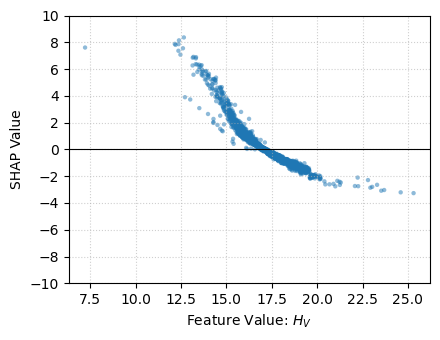

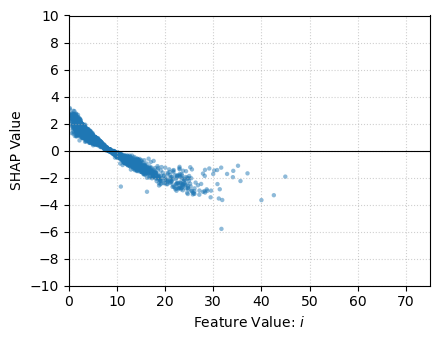

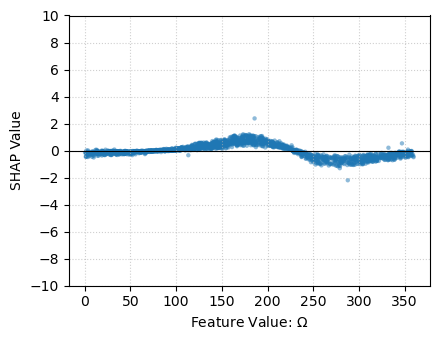

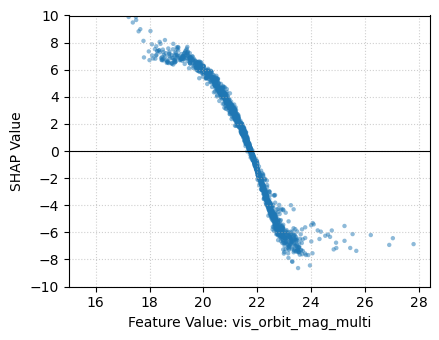

Saved 4 PGF files to additional code for paper/shap_simple_figures


In [ ]:
import sys, importlib
sys.path.insert(0, "additional code for paper")
import shap_simple
importlib.reload(shap_simple)

model_s, X_test_s, shap_values_s = shap_simple.run(
    train_data_reg.dropna()[['H', 'Node', 'i', 'vis_orbit_mag_multi', 'Num_opps_minus_one']],
    test_data_reg.dropna()[['H', 'Node', 'i', 'vis_orbit_mag_multi', 'Num_opps_minus_one']],
    out_dir="additional code for paper/shap_simple_figures",
)

## Some interesting plots

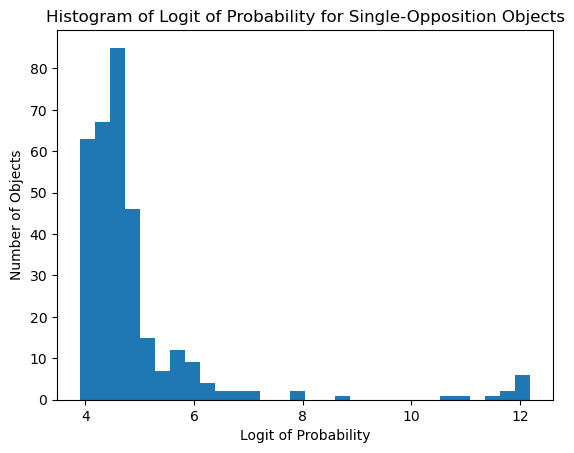

In [ ]:
%matplotlib inline
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# plot histogram of logit_prob
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>6)
      &(final["prob"]>0.98)
      # &(final["TJ"]>3.05)
      &(final["a"]>1.1)
      &(~final["a"].between(5,5.4))
      &(final["extension_difficulty"]<0.02)
      &(final["Orbital_period"]<20)].copy()
tempout["logit_prob"] = np.log(tempout["prob"]/(1-tempout["prob"]))

plt.hist(tempout["logit_prob"], bins=30)
plt.xlabel("Logit of Probability")
plt.ylabel("Number of Objects")
plt.title("Histogram of Logit of Probability for Single-Opposition Objects")
plt.show()

In [ ]:
tempout[tempout["prob"]>0.998][["Num_obs","Arc_length","U","prob","extension_difficulty","nights_total"]].sort_values("prob", ascending=False)

,Num_obs,Arc_length,U,prob,extension_difficulty,nights_total
Principal_desig,,,,,,
2008 BJ22,53,83,4,0.999995,0.000020,13.0
2019 OE31,32,137,3,0.999995,0.000466,10.0
2025 HV38,48,51,8,0.999995,0.000010,18.0
2007 VB146,13,16,10,0.999995,0.000279,4.0
2015 BC566,52,39,5,0.999994,0.000009,11.0
2025 VZ8,50,43,6,0.999994,0.000058,15.0
2001 BV70,32,50,10,0.999992,0.001665,8.0
2009 FP8,22,35,10,0.999991,0.000335,7.0
2021 AY8,24,101,4,0.999989,0.000053,7.0


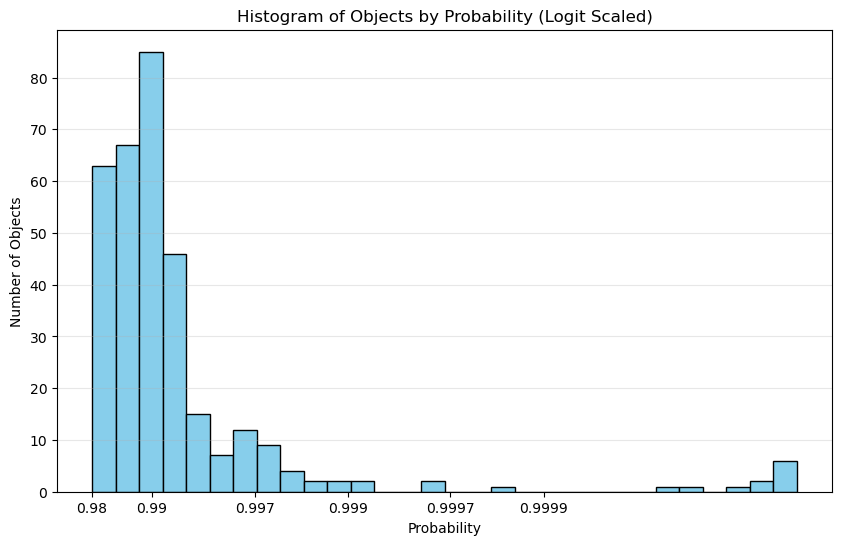

In [ ]:
# 1. Calculate logit as before
tempout["logit_prob"] = np.log(tempout["prob"] / (1 - tempout["prob"]))

# 2. Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(tempout["logit_prob"], bins=30, color='skyblue', edgecolor='black')

# 3. Define the probability values you want to see on the X-axis
# Since your filter is prob > 0.98, we choose values in that range
prob_ticks = np.array([0.98, 0.99, 0.997, 0.999, 0.9997, 0.9999])

# 4. Convert those probability labels into logit space for positioning
logit_ticks = np.log(prob_ticks / (1 - prob_ticks))

# 5. Apply the ticks and labels
plt.xticks(logit_ticks, labels=[f"{p}" for p in prob_ticks])

plt.xlabel("Probability")
plt.ylabel("Number of Objects")
plt.title("Histogram of Objects by Probability (Logit Scaled)")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import matplotlib
matplotlib.use("pgf")
# Optional: Configure PGF settings to automatically match your LaTeX document style
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
})

# Calculate logit as before
tempout["logit_prob"] = np.log(tempout["prob"] / (1 - tempout["prob"]))

# 2. Initialize the figure size using subplots
fig, ax = plt.subplots(figsize=(4.5, 2.5))
ax.hist(tempout["logit_prob"], bins=30, color='skyblue', edgecolor='black')

# 3. Define the probability values you want to see on the X-axis (where $prob > 0.98$)
prob_ticks = np.array([0.98, 0.99, 0.997, 0.999, 0.9997, 0.9999])

# 4. Convert those probability labels into logit space for positioning
logit_ticks = np.log(prob_ticks / (1 - prob_ticks))

# 5. Apply the ticks and labels to the axes
ax.set_xticks(logit_ticks)
ax.set_xticklabels([f"{p}" for p in prob_ticks])

ax.set_xlabel(r"$P(N_{\rm opp}\ge4)$")
ax.set_ylabel("Number of Objects")
# ax.set_title("Histogram of Objects by Probability (Logit Scaled)")
ax.grid(axis='y', alpha=0.3)

# 6. Save the figure as a .pgf file
plt.savefig("histogram.pgf", bbox_inches="tight")

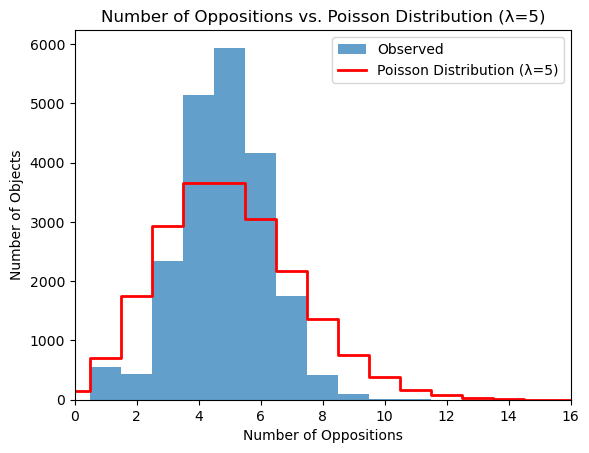

In [ ]:
# 1. Filter the data (as per your logic)
# Note: Filtering for 4.9 < x < 5.1 effectively selects objects where exp_Num_opps is 5

final_56 = final[(final["exp_Num_opps"] > 4.9) & (final["exp_Num_opps"] < 5.1)]
final_56 = final_56[final_56["Num_obs"] > 13]

# 2. Plot the histogram
# Bins [0.5, 1.5, 2.5...] center the bars on integers 1, 2, 3...
plt.hist(final_56["Num_opps"], bins=np.arange(0.5, 16.5, 1), alpha=0.7, label='Observed')

# 3. Prepare Poisson distribution data
x = np.arange(0, 17) # Range to cover the histogram bins
lambda_ = 5
poisson_pmf = poisson.pmf(x, lambda_)
# Scale PMF by the number of objects to match the histogram frequency
y = poisson_pmf * len(final_56)

# 4. Plot the red line as a stepwise function
# 'where='mid'' aligns the horizontal steps with the centers of the histogram bins
plt.step(x, y, color='red', where='mid', linewidth=2, label='Poisson Distribution (λ=5)')

# Formatting
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Number of Oppositions vs. Poisson Distribution (λ=5)")
plt.legend()
plt.xlim(0, 16)
plt.show()

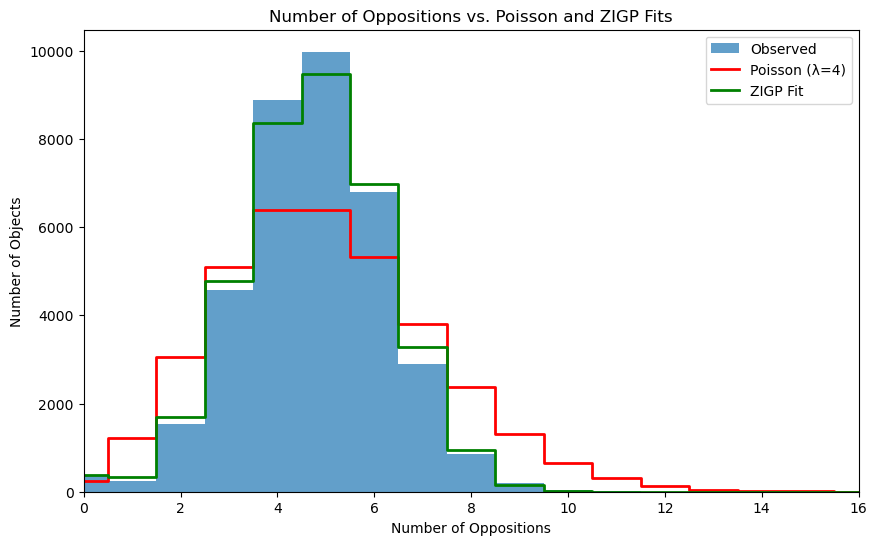

In [ ]:


# ... [Your previous data loading/filtering code] ...
# Assuming 'final' is already loaded as per your context

# 1. Filter the data
final_56 = final[(final["exp_Num_opps"] > 5.8) & (final["exp_Num_opps"] < 6.2)]
final_56 = final_56[final_56["Num_obs"] > 13]
final_56["exp_Num_Recov"] = final_56["exp_Num_opps"] - 1
final_56["Num_Recov"] = final_56["Num_opps"] - 1

# 2. Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(final_56["Num_Recov"], bins=np.arange(-0.5, 16.5, 1), alpha=0.7, label='Observed')

# 3. Prepare Poisson distribution data (Red Line)
x = np.arange(0, 17)
lambda_ = 5
poisson_pmf = poisson.pmf(x, lambda_)
y_poisson = poisson_pmf * len(final_56)
plt.step(x, y_poisson, color='red', where='mid', linewidth=2, label='Poisson (λ=4)')

# ---------------------------------------------------------
# 4. Fit ZIGP and Plot (Green Line)
# ---------------------------------------------------------

# Prepare data for Statsmodels
# We need an 'intercept' (column of 1s) to fit the mean of the distribution
endog = final_56["Num_Recov"]
exog = np.ones((len(endog), 1))

# Initialize and fit the ZIGP model
# inflation='logit' is the standard method for modeling the zero-inflation probability
zigp_model = sm.ZeroInflatedGeneralizedPoisson(endog, exog, inflation='logit')
res_zigp = zigp_model.fit(disp=0)  # disp=0 suppresses convergence messages

# Calculate predicted PMF
# We use a single dummy observation [1] to predict the distribution curve
exog_pred = np.array([[1.0]])
zigp_dist = res_zigp.get_distribution(exog=exog_pred)
zigp_pmf = zigp_dist.pmf(x) # Get PMF for x = 0..16

# Depending on statsmodels version, the output shape might vary. 
# We ensure it's a flat array matching 'x'
if zigp_pmf.ndim > 1:
    zigp_pmf = zigp_pmf.flatten()

# Scale to match histogram counts
y_zigp = zigp_pmf * len(final_56)

# Plot the green line
plt.step(x, y_zigp, color='green', where='mid', linewidth=2, label='ZIGP Fit')
# ---------------------------------------------------------

# Formatting
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Number of Oppositions vs. Poisson and ZIGP Fits")
plt.legend()
plt.xlim(0, 16)
plt.show()

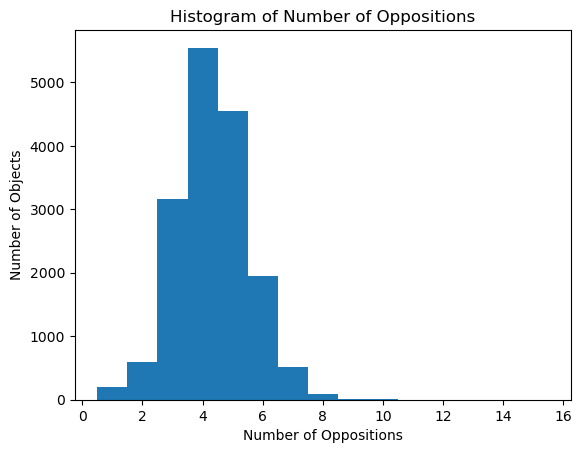

In [ ]:
# filter final for objects with exp_Num_opps between 5 and 6
final_56 = final[(final["exp_Num_opps"]>4) & (final["exp_Num_opps"]<4.2)]
final_56 = final_56[final_56["Num_obs"]>30]
# show a histogram of number of opps for final_56
plt.hist(final_56["Num_opps"], bins=np.arange(0.5, 16.5, 1))
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Histogram of Number of Oppositions")
plt.show()

# On to some tables, including the big one

In [ ]:
# Brightest objects with ____ or later initial linkage and designation
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(pd.to_numeric(final.index.str[0:4], errors="coerce")>=2025)
                &(pd.to_numeric(final.index.str[0:4], errors="coerce")<=2026)
                &(final["extension_difficulty"]<0.1)
      &(final["prob"]>0.999)]
tempout = tempout[cols_to_show]
tempout.head(20).to_clipboard()
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,prob,exp_Num_opps,Num_opps_diff,Num_opps_mult,extension_difficulty
Principal_desig,,,,,,,,,
2025 NC120,28,5,E2026-C66,<NA>,0.999962,10.356631,5.356631,2.071326,0.000026
2025 KM18,34,7,MPO924804,<NA>,0.999952,8.957286,1.957286,1.279612,0.000020
2025 XZ17,25,5,E2026-AB9,<NA>,0.999951,10.629379,5.629379,2.125876,0.000892
2025 MG255,49,8,E2026-C66,<NA>,0.999947,8.606545,0.606545,1.075818,0.000025
2025 SY25,35,6,MPO950837,<NA>,0.999947,10.296606,4.296606,1.716101,0.000023
2025 MJ165,49,6,E2026-E47,<NA>,0.999947,9.093942,3.093942,1.515657,0.000012
2025 AX10,82,9,MPO924222,<NA>,0.999945,9.205309,0.205309,1.022812,0.000104
2026 EX121,19,1,E2026-JD5,6,0.999916,11.016201,10.016201,11.016201,0.000132
2026 EC48,24,1,E2026-H99,6,0.999916,10.099419,9.099419,10.099419,0.000387


In [ ]:
# OUTPUT BIG TABLE FOR PAPER

for_paper = final.copy()
for_paper["Principal_desig"] = for_paper.index
for_paper["Object"] = for_paper["Number"].astype(str) + " " + for_paper["Principal_desig"]
# replace "<NA> " with ""
for_paper["Object"] = for_paper["Object"].str.replace("<NA> ", "")

import paper_table, importlib
importlib.reload(paper_table)

# Build one lookup frame from both sources (orbit-derived + comet-file objects)
combined = paper_table.combine_sources(for_paper, cometmerge)

# Render the full table; notes/group/asterisk come from the CSV
latex = paper_table.build_table(combined, "table_notes.csv")
print(latex)

\begin{longrotatetable}

\begin{longtable}{lrrrrrrrrrrl}
\caption{\activityscope\ candidates, recoveries, and false positives. Confirmed active objects are marked with an asterisk ($^{\ast}$).}
\label{tab:activityscope_results}\\
\toprule
Object & $a$ & $e$ & $i~(^\circ)$ &
$H_V$\tabnote{Absolute magnitude in the $V$ band, assuming an inert (point-source) object.} &
$T_J$\tabnote{Tisserand parameter with respect to Jupiter.} &
$N_{\rm opp}$\tabnote{Number of oppositions on which the object has been observed.} &
$E[N_{\rm opp}]$\tabnote{Expected number of observed oppositions for an inert object of the same orbit and $H_V$, predicted by the \activityscope\ Poisson regression model.} &
$P(N_{\rm opp}\ge4)$\tabnote{Binary-classifier probability that an inert object of the same orbit and $H_V$ would be observed on at least four oppositions; the primary anomaly ranking metric.} &
$\Delta Q$\tabnote{Quantile deficit $\Delta Q = Q_{0.006} - N_{\rm opp}$, where $Q_{0.006}$ is the model's $0.00

# Decision space scatter

['2003 BM80', '2008 GO98', '2010 RH69', '2017 QN84']


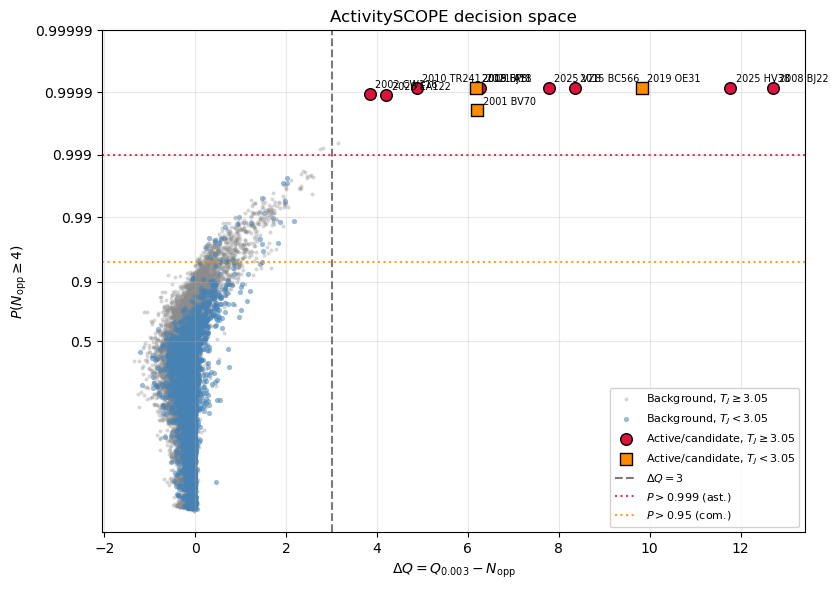

In [ ]:
#reload dss first
import decision_space_scatter as dss
import importlib
importlib.reload(dss)

fig, ax, info = dss.decision_space_scatter(final)
print(info["actives_missing"])
fig

In [ ]:
raise Exception("Stop here for now.")

Exception: Stop here for now.

# Nearest Neighbor Code
You can use this to troubleshoot or figure out why an object is getting the ratings it is getting.

In [ ]:
obj_to_examine = "2012 BG126"

nn_cols = ["vis_typ", "H", "e", "i", "node_plus_peri", "Peri", "Node"]#"Peri"] #"Tp", 
scaler = StandardScaler()
final_normalized = scaler.fit_transform(final[nn_cols])
nn = NearestNeighbors(n_neighbors=25)
nn.fit(final_normalized)
obj = final[final.index==obj_to_examine][nn_cols]
obj_normalized = scaler.transform(obj)
distances, indices = nn.kneighbors(obj_normalized)
out = final.iloc[indices[0]][["H","a","e","i", "Tp", "Node", "Peri", "Tp", "Num_opps", "extension_difficulty", "exp_Num_opps", "prob"]]
out.to_clipboard()
out

,H,a,e,i,Tp,Node,Peri,Tp,Num_opps,extension_difficulty,exp_Num_opps,prob
Principal_desig,,,,,,,,,,,,
2012 BG126,15.39,3.041732,0.082865,21.03676,2460258.95123,310.22647,278.46058,2460258.95123,8,0.000175,14.705095,0.999992
2009 BB97,15.32,3.101336,0.088202,20.4025,2461421.68992,317.99525,279.53566,2461421.68992,16,0.000175,15.097328,0.999987
2005 YK274,15.24,3.238312,0.078544,19.71457,2460713.35298,309.28534,280.08249,2460713.35298,11,0.000175,14.376964,0.999991
2001 XR265,15.36,3.212228,0.087201,21.79221,2461288.12088,293.62028,295.27425,2461288.12088,16,0.000175,13.267000,0.999990
2011 YX67,15.03,3.113697,0.106497,19.64384,2460499.01973,310.47646,282.54399,2460499.01973,14,0.000175,17.009636,0.999983
2009 BT28,15.47,3.142841,0.044506,20.8063,2461530.4537,308.14348,283.28166,2461530.4537,15,0.000175,13.100785,0.999986
2008 AL43,15.27,3.073904,0.068009,21.35645,2460714.40593,312.27526,247.9459,2460714.40593,14,0.000175,15.034163,0.999994
2015 QQ11,15.11,3.234569,0.089952,21.25263,2460550.45482,278.26638,281.88873,2460550.45482,14,0.000175,14.653041,0.999986
2015 MU91,15.38,3.231661,0.076463,20.90115,2461202.32648,305.91396,310.72713,2461202.32648,13,0.000175,13.130423,0.999992


# Variant Orbit Examination

In [ ]:
var_orbs = """00001   17.90  0.15 K262I 152.24281   27.64839  322.97462    1.63045  0.0823479  0.23441982   2.6049926    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [1]                 20260218
00002   17.83  0.15 K262I 160.20460   20.25129  323.07161    1.69034  0.0960834  0.23536447   2.5980178    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [2]                 20260218
00003   17.83  0.15 K262I 158.32285   21.80090  323.07219    1.69055  0.0967820  0.23528060   2.5986351    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [3]                 20260218
00004   17.59  0.15 K262I 174.49683    7.54475  323.38309    1.90854  0.1518294  0.23885153   2.5726697    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [4]                 20260218
00005   17.00  0.15 K262I 189.47235  357.52604  324.13476    2.68577  0.3310300  0.24986307   2.4965178    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [5]                 20260218
00006   18.20  0.15 K262I  98.34873   80.49982  322.55601    1.40728  0.0494537  0.23177571   2.6247670    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [6]                 20260218
00007   18.03  0.15 K262I 134.76390   44.61176  322.79552    1.52888  0.0615590  0.23307270   2.6150206    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [7]                 20260218
00008   17.63  0.15 K262I 174.93831    7.32511  323.34164    1.87653  0.1432720  0.23838381   2.5760337    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [8]                 20260218
00009   17.54  0.15 K262I 177.38891    5.25888  323.45241    1.96341  0.1657088  0.23973982   2.5663109    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [9]                 20260218
00010   17.23  0.15 K262I 184.88501  359.91143  323.84951    2.33632  0.2559067  0.24534987   2.5270403    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [10]                20260218
00011   17.69  0.15 K262I 168.65602   12.43568  323.25764    1.81519  0.1282929  0.23731491   2.5837631    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [11]                20260218
00012   17.64  0.15 K262I 170.75264   10.58060  323.31710    1.85855  0.1392735  0.23799215   2.5788592    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [12]                20260218
00013   17.46  0.15 K262I 177.69573    4.83165  323.56644    2.05974  0.1895489  0.24117820   2.5560971    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [13]                20260218
00014   17.64  0.15 K262I 170.97008   10.37586  323.32892    1.86728  0.1411996  0.23810404   2.5780512    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [14]                20260218
00015   17.37  0.15 K262I 181.92706    1.83058  323.67342    2.15745  0.2133049  0.24269613   2.5454280    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [15]                20260218
00016   17.58  0.15 K262I 175.29122    6.90915  323.40206    1.92346  0.1551241  0.23906166   2.5711619    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [16]                20260218
00017   17.43  0.15 K262I 180.47645    2.87352  323.59453    2.08449  0.1957380  0.24159396   2.5531638    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [17]                20260218
00018   17.30  0.15 K262I 183.61075    0.70410  323.76881    2.25111  0.2364933  0.24415886   2.5352515    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [18]                20260218
00019   17.98  0.15 K262I 144.47052   35.44622  322.86006    1.56389  0.0662710  0.23361318   2.6109857    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [19]                20260218
00020   17.69  0.15 K262I 171.14157   10.50217  323.25942    1.81645  0.1275482  0.23738192   2.5832769    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [20]                20260218
00021   18.42  0.15 K262I  58.61837  119.13291  322.24534    1.27096  0.0685787  0.23077435   2.6323544    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [21]                20260218
00022   17.90  0.15 K262I 154.63727   25.64290  322.97205    1.62874  0.0809547  0.23451997   2.6042509    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [22]                20260218
00023   18.07  0.15 K262I 127.62819   51.68413  322.73785    1.49790  0.0560880  0.23271670   2.6176868    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [23]                20260218
00024   17.50  0.15 K262I 177.25830    5.24655  323.50894    2.01014  0.1771184  0.24040262   2.5615918    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [24]                20260218
00025   17.83  0.15 K262I 158.13692   21.96326  323.06870    1.68853  0.0966867  0.23527649   2.5986654    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [25]                20260218
00026   18.23  0.15 K262I  90.22950   88.67651  322.50767    1.38467  0.0484954  0.23164083   2.6257858    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [26]                20260218
00027   18.10  0.15 K262I 122.86168   56.46823  322.69992    1.47853  0.0528094  0.23253554   2.6190462    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [27]                20260218
00028   17.90  0.15 K262I 153.29502   26.80185  322.96913    1.62736  0.0810596  0.23445425   2.6047376    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [28]                20260218
00029   18.01  0.15 K262I 139.89147   39.86926  322.81958    1.54161  0.0622460  0.23332778   2.6131144    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [29]                20260218
00030   17.55  0.15 K262I 175.73701    6.49505  323.43606    1.95031  0.1626016  0.23950401   2.5679951    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [30]                20260218
00031   17.97  0.15 K262I 143.53109   36.05389  322.87821    1.57434  0.0698641  0.23363202   2.6108453    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [31]                20260218
00032   17.73  0.15 K262I 167.73756   13.42313  323.19996    1.77505  0.1172632  0.23670640   2.5881893    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [32]                20260218
00033   17.58  0.15 K262I 174.36875    7.60207  323.39849    1.92033  0.1544570  0.23899112   2.5716678    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [33]                20260218
00034   18.13  0.15 K262I 113.07389   65.72607  322.65623    1.45588  0.0534425  0.23216266   2.6218497    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [34]                20260218
00035   18.29  0.15 K262I  78.63841  100.19070  322.43016    1.34970  0.0503050  0.23143086   2.6273738    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [35]                20260218
00036   17.81  0.15 K262I 161.14314   19.33251  323.09356    1.70422  0.0997693  0.23556823   2.5965194    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [36]                20260218
00037   18.15  0.15 K262I 111.68167   67.61835  322.62728    1.44192  0.0482069  0.23218722   2.6216648    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [37]                20260218
00038   17.73  0.15 K262I 169.76090   11.81115  323.20071    1.77517  0.1170121  0.23679414   2.5875500    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [38]                20260218
00039   17.52  0.15 K262I 176.63052    5.75203  323.47977    1.98581  0.1713605  0.24005356   2.5640743    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [39]                20260218
00040   17.93  0.15 K262I 151.83480   28.35642  322.93411    1.60621  0.0755780  0.23419810   2.6066365    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [40]                20260218
00041   17.94  0.15 K262I 148.67062   31.22994  322.91629    1.59602  0.0739880  0.23399549   2.6081409    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [41]                20260218
00042   17.92  0.15 K262I 152.12272   28.02475  322.94182    1.61114  0.0771341  0.23426332   2.6061527    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [42]                20260218
00043   17.60  0.15 K262I 173.62238    8.20246  323.38217    1.90778  0.1513624  0.23878918   2.5731175    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [43]                20260218
00044   17.54  0.15 K262I 175.64763    6.50300  323.46118    1.97057  0.1674085  0.23977672   2.5660476    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [44]                20260218
00045   17.84  0.15 K262I 158.59003   21.67040  323.05883    1.68169  0.0944826  0.23521540   2.5991153    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [45]                20260218
00046   17.61  0.15 K262I 173.21203    8.56699  323.36260    1.89274  0.1476462  0.23856800   2.5747077    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [46]                20260218
00047   17.37  0.15 K262I 180.79082    2.58771  323.67030    2.15475  0.2131202  0.24267445   2.5455796    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [47]                20260218
00048   17.85  0.15 K262I 159.55121   20.99661  323.04192    1.67144  0.0910009  0.23513063   2.5997399    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [48]                20260218
00049   18.10  0.15 K262I 124.37205   55.19942  322.69987    1.47811  0.0511035  0.23260921   2.6184932    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [49]                20260218
00050   17.72  0.15 K262I 169.50865   11.93818  323.21888    1.78825  0.1203812  0.23694634   2.5864418    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [50]                20260218
00051   17.43  0.15 K262I 178.80111    4.02335  323.59372    2.08388  0.1957434  0.24158214   2.5532470    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [51]                20260218
00052   17.65  0.15 K262I 172.74507    9.07527  323.31435    1.85646  0.1379218  0.23800893   2.5787380    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [52]                20260218
00053   17.84  0.15 K262I 162.12763   18.77037  323.05402    1.67937  0.0923907  0.23530694   2.5984412    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [53]                20260218
00054   17.79  0.15 K262I 163.09169   17.55393  323.12348    1.72366  0.1046646  0.23587397   2.5942751    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [54]                20260218
00055   17.88  0.15 K262I 159.31847   21.43566  323.00565    1.64935  0.0849453  0.23488711   2.6015365    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [55]                20260218
00056   17.66  0.15 K262I 172.43829    9.36452  323.29684    1.84363  0.1348104  0.23782135   2.5800937    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [56]                20260218
00057   17.19  0.15 K262I 185.60779  359.49318  323.89977    2.39165  0.2690798  0.24616319   2.5214710    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [57]                20260218
00058   18.00  0.15 K262I 142.85274   37.09591  322.83774    1.55144  0.0634243  0.23348133   2.6119685    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [58]                20260218
00059   17.89  0.15 K262I 156.20572   24.17638  322.98945    1.63915  0.0833612  0.23466866   2.6031508    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [59]                20260218
00060   17.78  0.15 K262I 165.42842   15.59073  323.13804    1.73328  0.1060494  0.23606970   2.5928410    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [60]                20260218
00061   17.65  0.15 K262I 170.87996   10.48934  323.31691    1.85829  0.1388468  0.23797096   2.5790122    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [61]                20260218
00062   17.93  0.15 K262I 151.44946   28.67069  322.93623    1.60771  0.0760182  0.23420436   2.6065901    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [62]                20260218
00063   17.82  0.15 K262I 160.57485   19.90174  323.07762    1.69424  0.0971648  0.23542468   2.5975748    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [63]                20260218
00064   17.69  0.15 K262I 169.85624   11.53057  323.25160    1.81084  0.1265887  0.23727992   2.5840171    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [64]                20260218
00065   17.97  0.15 K262I 145.24961   34.52159  322.88077    1.57592  0.0698343  0.23371671   2.6102145    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [65]                20260218
00066   18.02  0.15 K262I 138.40637   41.22127  322.81576    1.53934  0.0622543  0.23325092   2.6136884    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [66]                20260218
00067   17.74  0.15 K262I 166.56505   14.40737  323.18715    1.76612  0.1156393  0.23657561   2.5891432    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [67]                20260218
00068   18.03  0.15 K262I 134.84860   44.62910  322.79155    1.52620  0.0603271  0.23307295   2.6150187    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [68]                20260218
00069   17.65  0.15 K262I 171.60841    9.93165  323.31671    1.85840  0.1388761  0.23801842   2.5786694    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [69]                20260218
00070   17.90  0.15 K262I 152.57733   27.34976  322.97417    1.63041  0.0825719  0.23445602   2.6047244    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [70]                20260218
00071   17.92  0.15 K262I 152.63735   27.52119  322.95197    1.61683  0.0781173  0.23432540   2.6056923    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [71]                20260218
00072   17.99  0.15 K262I 141.52215   38.10700  322.85027    1.55853  0.0662199  0.23346304   2.6121050    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [72]                20260218
00073   17.74  0.15 K262I 166.61675   14.32353  323.19678    1.77292  0.1171897  0.23665646   2.5885535    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [73]                20260218
00074   17.75  0.15 K262I 167.51731   13.72856  323.17339    1.75680  0.1120746  0.23644093   2.5901263    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [74]                20260218
00075   17.78  0.15 K262I 162.90694   17.63822  323.13605    1.73203  0.1066703  0.23596497   2.5936082    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [75]                20260218
00076   17.84  0.15 K262I 162.67181   18.30935  323.05601    1.68023  0.0924533  0.23534281   2.5981772    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [76]                20260218
00077   17.89  0.15 K262I 153.51807   26.44370  322.98857    1.63875  0.0844073  0.23456310   2.6039317    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [77]                20260218
00078   17.78  0.15 K262I 164.13906   16.66117  323.13001    1.72822  0.1057232  0.23599356   2.5933987    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [78]                20260218
00079   18.10  0.15 K262I 120.06491   59.03347  322.69323    1.47460  0.0536524  0.23242834   2.6198514    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [79]                20260218
00080   17.93  0.15 K262I 149.59220   30.23110  322.93667    1.60820  0.0773171  0.23413041   2.6071389    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [80]                20260218
00081   17.76  0.15 K262I 166.07936   14.92245  323.16420    1.75057  0.1109926  0.23632420   2.5909792    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [81]                20260218
00082   17.90  0.15 K262I 154.39733   25.81719  322.97672    1.63171  0.0816262  0.23451880   2.6042596    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [82]                20260218
00083   17.98  0.15 K262I 145.91708   34.15588  322.86195    1.56521  0.0661434  0.23367592   2.6105183    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [83]                20260218
00084   17.53  0.15 K262I 177.04328    5.48254  323.46658    1.97509  0.1684478  0.23987877   2.5653198    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [84]                20260218
00085   17.91  0.15 K262I 151.84993   28.06986  322.96453    1.62463  0.0807946  0.23436187   2.6054220    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [85]                20260218
00086   17.50  0.15 K262I 178.64896    4.25859  323.50855    2.00974  0.1772906  0.24045467   2.5612221    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [86]                20260218
00087   17.28  0.15 K262I 183.43979    0.80884  323.78550    2.26858  0.2402142  0.24439006   2.5336524    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [87]                20260218
00088   17.90  0.15 K262I 154.67988   25.60787  322.97435    1.63032  0.0808569  0.23450570   2.6043566    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [88]                20260218
00089   17.43  0.15 K262I 179.17529    3.76381  323.59670    2.08620  0.1957061  0.24158447   2.5532306    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [89]                20260218
00090   17.18  0.15 K262I 187.62707  358.30563  323.91947    2.41440  0.2743552  0.24642827   2.5196625    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [90]                20260218
00091   17.87  0.15 K262I 154.14602   25.71812  323.01451    1.65440  0.0881926  0.23472738   2.6027166    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [91]                20260218
00092   17.70  0.15 K262I 169.78058   11.59571  323.25059    1.81052  0.1262871  0.23726518   2.5841242    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [92]                20260218
00093   17.77  0.15 K262I 166.39418   14.73995  323.14923    1.74100  0.1083621  0.23620997   2.5918144    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [93]                20260218
00094   17.92  0.15 K262I 151.99980   28.08050  322.95038    1.61588  0.0780598  0.23428990   2.6059555    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [94]                20260218
00095   17.47  0.15 K262I 178.94297    4.00309  323.54068    2.03715  0.1841863  0.24087478   2.5582432    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [95]                20260218
00096   17.68  0.15 K262I 169.94880   11.35247  323.27878    1.83055  0.1315972  0.23755172   2.5820457    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [96]                20260218
00097   17.80  0.15 K262I 163.47974   17.28499  323.11782    1.71969  0.1030122  0.23582043   2.5946678    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [97]                20260218
00098   17.93  0.15 K262I 150.33645   29.69307  322.92774    1.60280  0.0752077  0.23411609   2.6072452    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [98]                20260218
00099   17.50  0.15 K262I 177.94207    4.76676  323.50443    2.00629  0.1766940  0.24040133   2.5616009    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [99]                20260218
00100   17.65  0.15 K262I 171.40231   10.13319  323.30526    1.84961  0.1364320  0.23784767   2.5799034    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [100]               20260218
00101   18.04  0.15 K262I 137.56606   42.34088  322.78803    1.52458  0.0575773  0.23316755   2.6143114    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [101]               20260218
00102   17.50  0.15 K262I 177.77613    4.88964  323.50194    2.00410  0.1760410  0.24036354   2.5618694    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [102]               20260218
00103   17.89  0.15 K262I 157.44198   23.10152  322.99693    1.64401  0.0835225  0.23472714   2.6027184    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [103]               20260218
00104   18.20  0.15 K262I  97.13465   81.68562  322.55146    1.40499  0.0495504  0.23174124   2.6250274    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [104]               20260218
00105   17.61  0.15 K262I 173.12454    8.64746  323.35755    1.88897  0.1467323  0.23850379   2.5751697    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [105]               20260218
00106   17.93  0.15 K262I 150.68953   29.34034  322.93462    1.60665  0.0759541  0.23415440   2.6069608    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [106]               20260218
00107   17.62  0.15 K262I 172.70510    8.98621  323.34978    1.88313  0.1453935  0.23840775   2.5758613    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [107]               20260218
00108   17.41  0.15 K262I 179.88578    3.23824  323.62851    2.11567  0.2034440  0.24207055   2.5498115    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [108]               20260218
00109   17.79  0.15 K262I 163.16984   17.45471  323.12899    1.72753  0.1057622  0.23593221   2.5938482    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [109]               20260218
00110   18.04  0.15 K262I 132.55999   46.84725  322.77460    1.51728  0.0590063  0.23294721   2.6159597    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [110]               20260218
00111   17.43  0.15 K262I 179.92232    3.24506  323.60150    2.09116  0.1976791  0.24170726   2.5523658    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [111]               20260218
00112   17.70  0.15 K262I 168.24427   12.84166  323.23916    1.80216  0.1247056  0.23710116   2.5853158    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [112]               20260218
00113   18.11  0.15 K262I 118.95288   60.26110  322.67903    1.46752  0.0519275  0.23239807   2.6200789    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [113]               20260218
00114   17.69  0.15 K262I 168.76775   12.37221  323.25405    1.81261  0.1271287  0.23725244   2.5842167    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [114]               20260218
00115   17.61  0.15 K262I 173.45052    8.36567  323.37044    1.89854  0.1490525  0.23865061   2.5741134    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [115]               20260218
00116   17.70  0.15 K262I 169.14366   12.12168  323.24426    1.80578  0.1251112  0.23717098   2.5848083    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [116]               20260218
00117   17.87  0.15 K262I 156.90744   23.40272  323.01454    1.65440  0.0871986  0.23484700   2.6018327    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [117]               20260218
"""

In [ ]:
# parse these as fwf
mpc_names = ["Provis","H","G","Epoch","M","Peri","Node","i","e","n","a","ignore1","Num_obs","Num_opps","Arc_length","ignore2","Last_obs"]
mpc_widths = [7,6,6,6,10,11,11,11,11,12,12,13,6,4,5,63,8]

# take var_orbs as a string and turn it into a StringIO object
from io import StringIO
var_orbs_io = StringIO(var_orbs)

var_orb = pd.read_fwf(var_orbs_io, index_col=False, names=mpc_names, widths=mpc_widths, skiprows=0)


In [ ]:
# Define the character mappings based on the specifications
CENTURY_MAP = {'I': '18', 'J': '19', 'K': '20'}

# Generate Month Map: 1-9, then A-C
MONTH_CHARS = '123456789ABC'
MONTH_MAP = {char: str(idx + 1).zfill(2) for idx, char in enumerate(MONTH_CHARS)}

# Generate Day Map: 1-9, then A-V
DAY_CHARS = '123456789ABCDEFGHIJKLMNOPQRSTUV'
DAY_MAP = {char: str(idx + 1).zfill(2) for idx, char in enumerate(DAY_CHARS)}

def parse_packed_date(val):
    """
    Parses a single packed date string into a pandas Timestamp.
    """
    if pd.isna(val) or not isinstance(val, str) or len(val) < 5:
        return pd.NaT

    # Extract standard components
    cent_char = val[0].upper()
    yy = val[1:3]
    month_char = val[3].upper()
    day_char = val[4].upper()

    # Map to standard date strings
    century = CENTURY_MAP.get(cent_char)
    month = MONTH_MAP.get(month_char)
    day = DAY_MAP.get(day_char)

    # Validate that all parts were successfully mapped
    if not all([century, month, day]):
        return pd.NaT 

    # Formulate the base date
    base_date = pd.to_datetime(f"{century}{yy}-{month}-{day}")

    # Handle decimal fraction of the day if it exists
    if len(val) > 5:
        fraction_str = "0." + val[5:]
        fraction = float(fraction_str)
        # Add the fraction of the day as a timedelta
        base_date += pd.Timedelta(days=fraction)

    return base_date
var_orb["Epoch"] = var_orb["Epoch"].apply(parse_packed_date)

In [ ]:
var_orb

,Provis,H,G,Epoch,M,Peri,Node,i,e,n,a,ignore1,Num_obs,Num_opps,Arc_length,ignore2,Last_obs
0,Z0001Wf,19.7,0.15,2014-05-03,36.91684,316.09139,216.78131,2.31557,0.047127,0.304121,2.189972,9 OrbImp,14,1,2,days 0.07 M-v 3Ek Doppler 2.0867659 2456659.111297,20250419
1,Z0001Wg,20.0,0.15,2014-05-03,327.67978,231.97327,25.66523,2.73118,0.159702,0.280968,2.308688,9 OrbImp,12,1,2,days 0.08 M-v 3Ek Doppler 1.9399849 2456895.531827,20250419
2,Z0001Wh,18.6,0.15,2014-05-03,94.94818,236.03942,212.46378,1.12222,0.262186,0.247911,2.509606,9 OrbImp,13,1,2,days 0.09 M-v 3Ek Doppler 1.8516215 2456397.507061,20250419
3,Z0001Wj,17.2,0.15,2014-05-03,81.20165,39.21633,33.96953,3.20800,0.519560,0.158103,3.387213,9 OrbImp,10,1,2,days 0.07 M-v 3Ek Doppler 1.6273535 2456266.900522,20250419
4,Z0001Wk,17.7,0.15,2014-05-03,92.72233,80.74585,30.66991,18.32424,0.055861,0.170824,3.216892,9 OrbImp,14,1,2,days 0.06 M-v 3Ek Doppler 3.0371931 2456237.706087,20250419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51523,Z001iHJ,19.2,0.15,2025-09-22,356.76137,327.33566,54.65093,14.01944,0.194529,0.230575,2.633871,6 OrbImp,16,1,25,days 0.10 M-v 3Ek Doppler 2.1215063 2460954.545886,20251016
51524,Z001znR,16.8,0.15,2026-03-01,338.71091,11.68582,190.47631,7.42789,0.315687,0.146816,3.558659,7 OrbImp,18,1,8,days 0.18 M-v 3Ek Doppler 2.4352356 2461245.504862,20260228
51525,Z001ks9,19.7,0.15,2025-10-12,42.38899,199.20046,120.04318,3.56103,0.210973,0.272285,2.357510,5 OrbImp,19,1,30,days 0.27 M-v 3Ek Doppler 1.8601405 2460804.821219,20251105
51526,Z001y3t,16.8,0.15,2025-08-13,0.02406,151.97100,68.64736,144.24627,0.983234,0.000377,189.733253,5 OrbImp,21,1,39,days 0.19 M-v 3Ek Doppler 3.1810285 2460836.689834,20260202


In [ ]:
# calculate the model predictions for these
var_orb["Perihelion_dist"] = var_orb["a"] * (1-var_orb["e"])
var_orb["Orbital_period"] = (var_orb["a"].to_numpy())**1.5
var_orb = utils.feature_engineering(var_orb)
var_orb["exp_Num_opps"] = predictor_reg.predict(var_orb) + 1
var_orb["quantile_Opps"] = predictor_quant.predict(var_orb)[0.006] + 1
var_orb["prob"] = predictor.predict_proba(var_orb)[1]

var_orb

,Provis,H,G,Epoch,M,Peri,Node,i,e,n,...,vis_orbit_flux_opp,vis_mag_timeavg,vis_orbit_flux_multi,vis_orbit_mag_multi,vis_last_perihelion,perihelion_delta_true,perihelion_dec_true,exp_Num_opps,quantile_Opps,prob
0,Z0001Wf,19.7,0.15,2014-05-03,36.91684,316.09139,216.78131,2.31557,0.047127,0.304121,...,21.931298,21.951470,22.708400,23.049299,23.255777,1.436177,-0.164406,3.894764,0.984550,0.637358
1,Z0001Wg,20.0,0.15,2014-05-03,327.67978,231.97327,25.66523,2.73118,0.159702,0.280968,...,22.397095,22.600578,23.170164,23.623382,23.838224,1.644244,-0.431145,2.390122,0.988731,0.186226
2,Z0001Wh,18.6,0.15,2014-05-03,94.94818,236.03942,212.46378,1.12222,0.262186,0.247911,...,21.101111,21.643123,21.909437,22.626515,22.358637,2.834504,0.398071,7.327197,3.417457,0.994637
3,Z0001Wj,17.2,0.15,2014-05-03,81.20165,39.21633,33.96953,3.20800,0.519560,0.158103,...,20.107932,22.142468,20.965247,22.834003,19.780004,1.015930,0.439658,6.166714,2.776446,0.975538
4,Z0001Wk,17.7,0.15,2014-05-03,92.72233,80.74585,30.66991,18.32424,0.055861,0.170824,...,22.381731,22.411997,22.826077,22.929052,23.440824,2.947258,0.613922,2.858047,0.984160,0.296095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51523,Z001iHJ,19.2,0.15,2025-09-22,356.76137,327.33566,54.65093,14.01944,0.194529,0.230575,...,22.589792,22.854462,23.193935,23.551417,22.625071,1.376605,0.095000,2.030819,0.982825,0.064911
51524,Z001znR,16.8,0.15,2026-03-01,338.71091,11.68582,190.47631,7.42789,0.315687,0.146816,...,21.291619,21.914979,21.868053,22.495944,21.774799,2.417456,-0.265594,6.243056,2.694146,0.982036
51525,Z001ks9,19.7,0.15,2025-10-12,42.38899,199.20046,120.04318,3.56103,0.210973,0.272285,...,22.109048,22.468460,22.889277,23.450468,23.410073,1.569286,-0.415841,2.444263,0.984904,0.182098
51526,Z001y3t,16.8,0.15,2025-08-13,0.02406,151.97100,68.64736,144.24627,0.983234,0.000377,...,29.806542,41.070313,30.137977,41.088500,22.104095,2.471521,-0.032033,1.229682,0.845926,0.011843


In [ ]:
# # ad hoc
# var_orb[(var_orb["prob"] > 0.999)
#         & (var_orb["Arc_length"].between(7,20))
#         & (var_orb["Epoch"].between(pd.Timestamp("2009-01-01"), pd.Timestamp("2015-01-01")))]

,Provis,H,G,Epoch,M,Peri,Node,i,e,n,...,vis_orbit_flux_opp,vis_mag_timeavg,vis_orbit_flux_multi,vis_orbit_mag_multi,vis_last_perihelion,perihelion_delta_true,perihelion_dec_true,exp_Num_opps,quantile_Opps,prob
319,Z001Bvr,17.2,0.15,2013-11-24,322.14976,281.67795,186.75332,8.41332,0.164295,0.181823,...,21.375425,21.543107,21.929339,22.192899,21.205674,1.713218,0.189859,9.103936,5.152739,0.999354
335,Z001RUu,16.5,0.15,2014-03-04,262.86136,122.85949,168.85955,2.34143,0.269746,0.182081,...,20.241501,20.729514,20.911877,21.482374,21.441169,2.648010,-0.263157,14.461700,10.083965,0.999997
6039,Z001tIQ,14.4,0.15,2013-10-15,75.16217,282.90098,8.25851,14.78981,0.085999,0.086930,...,21.176294,21.217605,21.501876,21.576297,20.991303,3.688763,-0.677126,11.521753,7.866276,0.999995
6166,Z001tIk,17.2,0.15,2013-11-04,45.67389,116.47881,210.82277,13.52975,0.222700,0.217181,...,20.749520,21.067904,21.340571,21.738003,19.924167,1.172664,0.117260,9.846926,5.770650,0.999985
32677,Z001X8q,17.1,0.15,2012-10-20,293.33711,262.72872,216.43756,4.14788,0.094702,0.204231,...,20.857071,20.917190,21.471394,21.688307,22.167298,2.415576,0.329774,13.025463,9.010742,0.999985
32679,Z001X8F,16.5,0.15,2013-09-25,247.60026,295.68173,201.09911,4.34763,0.090358,0.173890,...,20.832922,20.884973,21.394200,21.570861,22.136099,2.938690,0.295874,14.324795,10.434327,0.999996
38246,Z001oki,14.7,0.15,2014-04-13,252.79887,331.60676,51.10809,12.39693,0.852243,0.182480,...,17.292446,20.478561,18.084203,20.820031,15.514911,1.055980,-0.328854,19.800964,14.635109,0.999998


# Quantile Level Tuner
This is how we empirically picked the quantile level for the quantile model (0.006)

Excluding 2 rows for designations: ['2015 LT68', '2026 EX121']


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.26 GB / 32.00 GB (19.6%)
Disk Space Avail:   51.45 GB / 926.35 GB (5.6%)
Presets specified: ['good_quality']
Using hyperparameters preset: hyperparameters='light'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid th


=== quantile_level = 0.003  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.003_20260522_162230) ===


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.003_20260522_162230"
Train Data Rows:    906817
Train Data Columns: 18
Label Column:       Num_opps_minus_one
Problem Type:       quantile
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6411.13 MB
	Train Data (Original)  Memory Usage: 62.27 MB (1.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original d

  AUC=1.0000  min_gap=0.602  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']

=== quantile_level = 0.006  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.006_20260522_162230) ===


...

  AUC=1.0000  min_gap=0.235  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']

=== quantile_level = 0.13  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.13_20260522_162230) ===


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.13_20260522_162230"
Train Data Rows:    906817
Train Data Columns: 18
Label Column:       Num_opps_minus_one
Problem Type:       quantile
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6333.52 MB
	Train Data (Original)  Memory Usage: 62.27 MB (1.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original da

  AUC=1.0000  min_gap=0.120  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']

=== quantile_level = 0.25  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.25_20260522_162230) ===


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.25_20260522_162230"
Train Data Rows:    906817
Train Data Columns: 18
Label Column:       Num_opps_minus_one
Problem Type:       quantile
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6759.45 MB
	Train Data (Original)  Memory Usage: 62.27 MB (0.9% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original da

  AUC=1.0000  min_gap=0.079  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']
{'best_quantile_level': 0.006, 'best_auc': 1.0, 'best_min_gap': 1.0235986709594727, 'tiebreak_used': True}


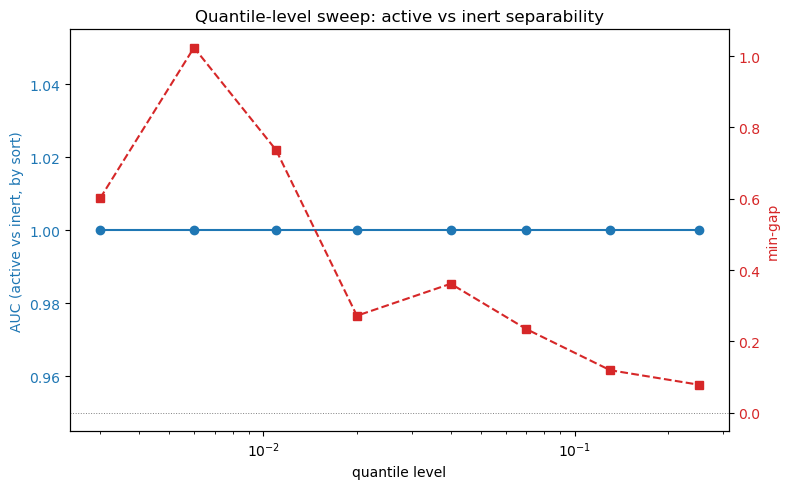

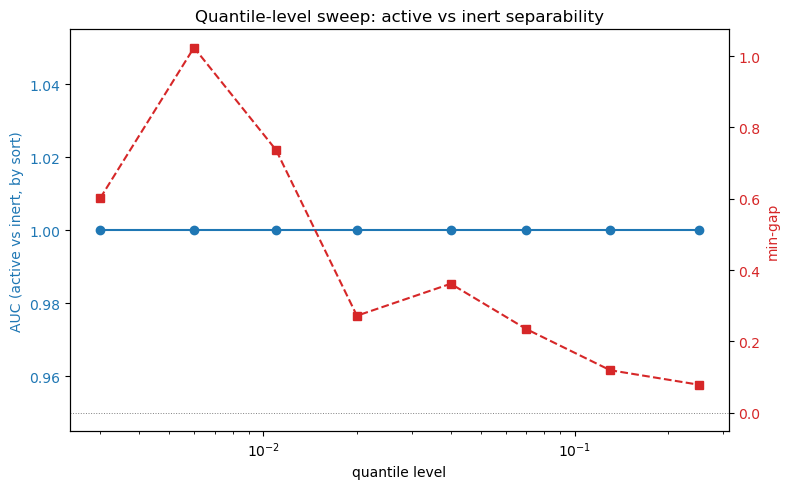

In [ ]:
# Quantile tuner goes here where we will import it and run it based on data_df_reg
import quantile_tuner as qt
import importlib
importlib.reload(qt)

artifacts, results, summary = qt.tune(
    data_df_reg=data_df_reg,
    eval_data=orb_pred,          # or orb/final — needs Num_opps, extension_difficulty, a, Principal_desig
    quantile_levels=[0.003, 0.006, 0.011, 0.02, 0.040, 0.07, 0.13, 0.25],
    # fast=True,
)
print(summary)                   # {"best_quantile_level": ..., "best_auc": ..., "best_min_gap": ..., "tiebreak_used": ...}
qt.plot_separability(results)

In [ ]:
results

,quantile_level,auc,min_gap,min_active_sort,max_inert_sort,n_active,n_inert
0,0.003,1.0,0.601628,3.379683,2.778055,14,1155793
1,0.006,1.0,1.023599,4.293551,3.269953,14,1155793
2,0.011,1.0,0.736735,4.657668,3.920933,14,1155793
3,0.020,1.0,0.272206,4.718336,4.446130,14,1155793
4,0.040,1.0,0.361768,5.065926,4.704157,14,1155793
5,0.070,1.0,0.234661,5.481317,5.246656,14,1155793
6,0.130,1.0,0.119503,6.017932,5.898429,14,1155793
7,0.250,1.0,0.078939,6.518692,6.439753,14,1155793


# Curiosities

In [ ]:
# A curiousity: some of the most over-observed objects!
final_low = final[(final["exp_Num_opps"]>1) & (final["exp_Num_opps"]<1.5)]
final_low = final_low[final_low["Num_obs"]>13]
final_low = final_low[final_low["q"]>=1.3]

final_low.sort_values(by="poisson_cdf", ascending=False)[['Number','H','Num_opps','poisson_cdf','exp_Num_opps','prob']]